# SSTD EEG — Subject-Independent Left/Right Motor-Imagery Classification

### Clean, cell-by-cell implementation

This notebook is the cleaned version of the original two-class EEG pipeline. The **computational logic is preserved**; only the legacy project/class/file naming has been removed so the implementation is presented consistently as a **Spectral-Spatial-Temporal Domain Adaptation (SSTD)** model.

**Task:** Left Fist vs Right Fist  
**Dataset:** PhysioNet EEGMMIDB  
**Runs:** 4, 8, 12  
**Input:** 22 channels × 750 samples (250 Hz, 0.5–3.5 s)

### Notebook flow
1. Imports and configuration
2. Reproducibility and device
3. EEG event handling and dataset construction
4. Gradient reversal, Sinc filters, Dynamic GNN, BiGRU, SE attention
5. Main model, SupCon, AdaBN
6. Subject-independent training/evaluation
7. Paper-ready infographic and result plots
8. Validation → experiment → figure display


## Architecture at a glance

```text
Raw EEG (22 × 750)
        │
        ▼
Per-trial / per-channel Z-score
        │
        ▼
Learnable Sinc Filter Bank (10 bands)
        │
        ▼
Dynamic Graph Neural Network (22 nodes → 64 features)
        │
        ▼
Frequency Mean Pooling
        │
        ▼
Bidirectional GRU (32 + 32 = 64)
        │
        ▼
SE Attention (64 → 4 → 64)
        │
        ▼
64-D latent representation
     ┌──┴───────────────┐
     ▼        ▼         ▼
  Task     GRL +      SupCon
Classifier Domain      Head
     │     Classifier
     ▼        ▼
Left/Right  Subject-
Fist        invariant
            features
        │
        ▼
Target-time AdaBN
        │
        ▼
Final prediction
```

**Core idea:** spectral learning → spatial/channel interaction → temporal learning → feature reweighting → subject-invariant adaptation.


## 0. Imports

In [1]:
# 0. IMPORTS
# ============================================================

import os
import math
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.manifold import TSNE


warnings.filterwarnings("ignore")

mne.set_log_level("ERROR")


# ============================================================

## 1. Global Configuration

In [23]:
# 1. GLOBAL CONFIGURATION
# ============================================================

SEED = 42

DATA_DIR = "./eegmmidb"


# ============================================================
# DATASET SETTINGS
# ============================================================

TOTAL_SUBJECTS = 109

NUM_TRAIN_SUBJECTS = 99

NUM_TEST_FOLDS = 10


# ============================================================
# TWO-CLASS SETTINGS
# ============================================================

NUM_CLASSES = 2

CLASS_NAMES = [
    "Left Fist",
    "Right Fist"
]


# IMPORTANT:
# Only unilateral hand motor imagery runs.

RUNS = [
    4,
    8,
    12
]


# ============================================================
# EEG SETTINGS
# ============================================================

FS = 250.0

N_CHANNELS = 22

TMIN = 0.5

TMAX = 3.5

TRIAL_DURATION = TMAX - TMIN

N_SAMPLES = int(
    round(
        TRIAL_DURATION * FS
    )
)


assert N_SAMPLES == 750, (
    f"Expected 750 samples, "
    f"but got {N_SAMPLES}"
)


# ============================================================
# TRAINING SETTINGS
# ============================================================

BATCH_SIZE = 64

EPOCHS = 100

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.1

DOMAIN_WEIGHT = 1.0

SUPCON_WEIGHT = 0.5

SUPCON_TEMPERATURE = 0.07

GRADIENT_CLIP = 1.0


# ============================================================
# MODEL SETTINGS
# ============================================================

NUM_FILTERS = 10

SINC_KERNEL_SIZE = 81

SPATIAL_DIM = 64


# ============================================================
# EVALUATION MODE
# ============================================================
#
# PROJECT
#   Reproduces your existing ten target subjects.
#
# RANDOM
#   Selects ten targets reproducibly.
#
# EXHAUSTIVE
#   Every subject becomes a target.
#
# ============================================================

EVAL_MODE = "PROJECT"


CURATED_TEST_POOL = [
    4,
    15,
    23,
    29,
    31,
    42,
    55,
    71,
    
]


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

RESULTS_DIR = Path(
    "./results_sstd_da_2class"
)

FIG_DIR = (
    RESULTS_DIR
    / "figures"
)


RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================

## 2. Reproducibility

In [24]:
# 2. REPRODUCIBILITY
# ============================================================

def seed_everything(
    seed=SEED
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


seed_everything()


# ============================================================

## 3. Device

In [25]:
# 3. DEVICE
# ============================================================

if torch.cuda.is_available():

    DEVICE = torch.device(
        "cuda"
    )

elif torch.backends.mps.is_available():

    DEVICE = torch.device(
        "mps"
    )

else:

    DEVICE = torch.device(
        "cpu"
    )


print("=" * 80)

print(
    "SSTD_DomainAdaptationModel "
    "TWO-CLASS LEFT/RIGHT HAND PIPELINE"
)

print("=" * 80)

print(
    f"Device: {DEVICE}"
)

print(
    f"Input shape: "
    f"({N_CHANNELS}, {N_SAMPLES})"
)

print(
    f"Sampling rate: "
    f"{FS} Hz"
)

print(
    f"Window: "
    f"{TMIN} s -> {TMAX} s"
)

print(
    f"Classes: "
    f"{CLASS_NAMES}"
)

print(
    f"Runs: "
    f"{RUNS}"
)

print("=" * 80)


# ============================================================

SSTD_DomainAdaptationModel TWO-CLASS LEFT/RIGHT HAND PIPELINE
Device: mps
Input shape: (22, 750)
Sampling rate: 250.0 Hz
Window: 0.5 s -> 3.5 s
Classes: ['Left Fist', 'Right Fist']
Runs: [4, 8, 12]


## 4. Mne Event Handling

In [26]:
# 4. MNE EVENT HANDLING
# ============================================================

def normalize_annotation_name(
    name
):

    if name is None:

        return ""

    return str(
        name
    ).strip().upper()


def get_actual_event_ids(
    raw
):

    """
    Critical fix.

    MNE assigns numerical event IDs dynamically from the
    annotation descriptions.

    Therefore we MUST NOT assume:

        T1 = 0
        T2 = 1

    We discover the actual IDs first.
    """


    events, event_dict = \
        mne.events_from_annotations(
            raw,
            verbose=False
        )


    normalized_event_dict = {}


    for key, value in event_dict.items():

        normalized_event_dict[
            normalize_annotation_name(
                key
            )
        ] = value


    t1_id = \
        normalized_event_dict.get(
            "T1",
            None
        )


    t2_id = \
        normalized_event_dict.get(
            "T2",
            None
        )


    return (
        events,
        normalized_event_dict,
        t1_id,
        t2_id
    )


# ============================================================

## 5. Two-Class Eegmmidb Dataset

In [27]:
# 5. TWO-CLASS EEGMMIDB DATASET
# ============================================================

class EEGMMIDB_Dataset(
    Dataset
):


    def __init__(
        self,
        data_dir,
        subjects,
        runs=RUNS,
        tmin=TMIN,
        tmax=TMAX
    ):

        self.data_dir = str(
            data_dir
        )

        self.subjects = list(
            subjects
        )

        self.runs = list(
            runs
        )

        self.tmin = tmin

        self.tmax = tmax


        self.epochs = []

        self.labels = []

        self.subject_ids = []

        self.run_ids = []


        self.load_data()


    # ========================================================
    # LOAD DATA
    # ========================================================

    def load_data(
        self
    ):

        print(
            "\nLoading subjects:",
            self.subjects
        )


        for subject in self.subjects:

            subject_folder = (
                f"S{subject:03d}"
            )


            subject_path = os.path.join(
                self.data_dir,
                subject_folder
            )


            if not os.path.exists(
                subject_path
            ):

                print(
                    f"[WARNING] "
                    f"Missing "
                    f"{subject_folder}"
                )

                continue


            for run in self.runs:

                edf_file = os.path.join(
                    subject_path,
                    f"{subject_folder}"
                    f"R{run:02d}.edf"
                )


                if not os.path.exists(
                    edf_file
                ):

                    print(
                        f"[WARNING] "
                        f"Missing "
                        f"{subject_folder}"
                        f"R{run:02d}.edf"
                    )

                    continue


                # ====================================================
                # FOR RUNS 4/8/12:
                #
                # T1 = LEFT FIST
                # T2 = RIGHT FIST
                # ====================================================

                t1_class = 0

                t2_class = 1


                try:

                    # ==================================================
                    # LOAD EDF
                    # ==================================================

                    raw = mne.io.read_raw_edf(
                        edf_file,
                        preload=True,
                        verbose=False
                    )


                    # ==================================================
                    # CHANNEL CHECK
                    # ==================================================

                    if len(
                        raw.ch_names
                    ) < N_CHANNELS:

                        print(
                            f"[WARNING] "
                            f"{subject_folder}"
                            f"R{run:02d}: "
                            f"only "
                            f"{len(raw.ch_names)} "
                            f"channels"
                        )

                        continue


                    # ==================================================
                    # FIRST 22 CHANNELS
                    # ==================================================

                    raw.pick(
                        raw.ch_names[
                            :N_CHANNELS
                        ]
                    )


                    # ==================================================
                    # RESAMPLE TO 250 Hz
                    # ==================================================

                    raw.resample(
                        FS,
                        npad="auto"
                    )


                    # ==================================================
                    # DISCOVER ACTUAL MNE EVENT IDS
                    # ==================================================

                    (
                        events,
                        event_dict,
                        t1_id,
                        t2_id
                    ) = get_actual_event_ids(
                        raw
                    )


                    # ==================================================
                    # VERIFY EVENTS
                    # ==================================================

                    if (
                        t1_id is None
                        or
                        t2_id is None
                    ):

                        print(
                            f"[WARNING] "
                            f"{subject_folder}"
                            f"R{run:02d}: "
                            f"T1/T2 not found"
                        )

                        print(
                            "Available "
                            "annotations:",
                            list(
                                event_dict.keys()
                            )
                        )

                        continue


                    # ==================================================
                    # EXTRACT T1
                    # ==================================================

                    t1_events = events[
                        events[:, 2]
                        ==
                        t1_id
                    ].copy()


                    # ==================================================
                    # EXTRACT T2
                    # ==================================================

                    t2_events = events[
                        events[:, 2]
                        ==
                        t2_id
                    ].copy()


                    if (
                        len(t1_events) == 0
                        or
                        len(t2_events) == 0
                    ):

                        print(
                            f"[WARNING] "
                            f"{subject_folder}"
                            f"R{run:02d}: "
                            f"T1={len(t1_events)} "
                            f"T2={len(t2_events)}"
                        )

                        continue


                    # ==================================================
                    # REMAP TO 0/1
                    # ==================================================

                    selected_events = []


                    # T1 -> Left Fist = 0

                    for event in t1_events:

                        new_event = \
                            event.copy()

                        new_event[2] = \
                            t1_class

                        selected_events.append(
                            new_event
                        )


                    # T2 -> Right Fist = 1

                    for event in t2_events:

                        new_event = \
                            event.copy()

                        new_event[2] = \
                            t2_class

                        selected_events.append(
                            new_event
                        )


                    selected_events = \
                        np.asarray(
                            selected_events,
                            dtype=int
                        )


                    # ==================================================
                    # CHRONOLOGICAL SORT
                    # ==================================================

                    selected_events = \
                        selected_events[
                            np.argsort(
                                selected_events[:, 0]
                            )
                        ]


                    # ==================================================
                    # EVENT ID MAPPING
                    # ==================================================

                    event_id_mapping = {

                        "Left Fist": 0,

                        "Right Fist": 1

                    }


                    # ==================================================
                    # CREATE EPOCHS
                    # ==================================================

                    epochs = mne.Epochs(

                        raw,

                        selected_events,

                        event_id=
                            event_id_mapping,

                        tmin=
                            self.tmin,

                        tmax=(
                            self.tmax
                            -
                            1.0 / FS
                        ),

                        baseline=None,

                        preload=True,

                        reject_by_annotation=True,

                        verbose=False
                    )


                    # ==================================================
                    # GET DATA
                    # ==================================================

                    data = epochs.get_data()


                    labels = \
                        epochs.events[:, -1]


                    # ==================================================
                    # VALIDATE SHAPE
                    # ==================================================

                    valid_count = 0


                    for i in range(
                        len(data)
                    ):

                        if data[i].shape != (
                            N_CHANNELS,
                            N_SAMPLES
                        ):

                            print(
                                f"[WARNING] "
                                f"Bad shape "
                                f"{subject_folder}"
                                f"R{run:02d}: "
                                f"{data[i].shape}"
                            )

                            continue


                        self.epochs.append(
                            data[i].astype(
                                np.float32
                            )
                        )


                        self.labels.append(
                            int(
                                labels[i]
                            )
                        )


                        self.subject_ids.append(
                            int(
                                subject - 1
                            )
                        )


                        self.run_ids.append(
                            int(
                                run
                            )
                        )


                        valid_count += 1


                    print(
                        f"[OK] "
                        f"{subject_folder}"
                        f"R{run:02d} | "
                        f"T1={len(t1_events)} | "
                        f"T2={len(t2_events)} | "
                        f"Epochs={valid_count}"
                    )


                except Exception as e:

                    print(
                        f"[ERROR] "
                        f"{subject_folder}"
                        f"R{run:02d}: "
                        f"{type(e).__name__}: "
                        f"{e}"
                    )

                    continue


        # ========================================================
        # DATASET SUMMARY
        # ========================================================

        print(
            "\n"
            + "-" * 70
        )


        print(
            f"DATASET COMPLETE | "
            f"Trials={len(self.epochs)}"
        )


        print(
            "Labels:",
            Counter(
                self.labels
            )
        )


        print(
            "Runs:",
            Counter(
                self.run_ids
            )
        )


        print(
            "Subjects:",
            len(
                set(
                    self.subject_ids
                )
            )
        )


        print(
            "-" * 70
        )


    # ========================================================
    # LENGTH
    # ========================================================

    def __len__(
        self
    ):

        return len(
            self.epochs
        )


    # ========================================================
    # ITEM
    # ========================================================

    def __getitem__(
        self,
        idx
    ):

        x = torch.tensor(
            self.epochs[idx],
            dtype=torch.float32
        )


        y = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )


        s = torch.tensor(
            self.subject_ids[idx],
            dtype=torch.long
        )


        # ====================================================
        # PER-TRIAL, PER-CHANNEL Z-SCORE
        # ====================================================

        mean = x.mean(
            dim=1,
            keepdim=True
        )


        std = x.std(
            dim=1,
            keepdim=True
        )


        x = (
            x - mean
        ) / (
            std + 1e-6
        )


        return (
            x,
            y,
            s
        )


# ============================================================

## 6. Available Subjects

In [28]:
# 6. AVAILABLE SUBJECTS
# ============================================================

def available_subjects(
    data_dir,
    max_subjects=TOTAL_SUBJECTS
):

    subjects = []


    for subject in range(
        1,
        max_subjects + 1
    ):

        folder = (
            Path(data_dir)
            /
            f"S{subject:03d}"
        )


        if folder.is_dir():

            subjects.append(
                subject
            )


    return subjects


# ============================================================

## 7. Validate One Subject

In [29]:
# 7. VALIDATE ONE SUBJECT
# ============================================================

def validate_subject(
    data_dir,
    subject
):

    print(
        "\n"
        + "=" * 80
    )


    print(
        f"VALIDATING S{subject:03d}"
    )


    print(
        "=" * 80
    )


    dataset = EEGMMIDB_Dataset(
        data_dir,
        [
            subject
        ]
    )


    label_counts = Counter(
        dataset.labels
    )


    run_counts = Counter(
        dataset.run_ids
    )


    print(
        "\nTotal trials:",
        len(dataset)
    )


    print(
        "Label counts:",
        dict(label_counts)
    )


    print(
        "Run counts:",
        dict(run_counts)
    )


    missing = [

        c

        for c in range(
            NUM_CLASSES
        )

        if c not in label_counts

    ]


    if missing:

        raise RuntimeError(
            "Missing classes: "
            +
            str(
                [
                    CLASS_NAMES[c]
                    for c in missing
                ]
            )
        )


    print(
        "\nSUCCESS:"
    )


    print(
        "Both Left Fist and "
        "Right Fist are present."
    )


    return dataset


# ============================================================

## 8. Gradient Reversal

In [30]:
# 8. GRADIENT REVERSAL
# ============================================================

class GradientReversalLayer(
    torch.autograd.Function
):


    @staticmethod
    def forward(
        ctx,
        x,
        lambda_grl
    ):

        ctx.lambda_grl = \
            lambda_grl

        return x.view_as(
            x
        )


    @staticmethod
    def backward(
        ctx,
        grad_output
    ):

        return (
            grad_output.neg()
            *
            ctx.lambda_grl,
            None
        )


def grl(
    x,
    lambda_grl=1.0
):

    return GradientReversalLayer.apply(
        x,
        lambda_grl
    )


# ============================================================

## 9. Learnable Sinc Filter Bank

In [31]:
# 9. LEARNABLE SINC FILTER BANK
# ============================================================

class SincFilterBank(
    nn.Module
):


    def __init__(
        self,
        in_channels=22,
        num_filters=10,
        kernel_size=81,
        sample_rate=250
    ):

        super().__init__()


        self.num_filters = \
            num_filters


        self.kernel_size = \
            kernel_size


        self.sample_rate = \
            sample_rate


        self.f1 = nn.Parameter(
            torch.rand(
                num_filters
            )
            *
            10
            +
            5
        )


        self.f2 = nn.Parameter(
            torch.rand(
                num_filters
            )
            *
            20
            +
            15
        )


    def forward(
        self,
        x
    ):

        B, C, T = x.shape


        n = torch.arange(

            -(
                self.kernel_size
                //
                2
            ),

            (
                self.kernel_size
                //
                2
            )
            + 1,

            device=x.device,

            dtype=x.dtype

        )


        filters = []


        for i in range(
            self.num_filters
        ):

            f1_scaled = (
                self.f1[i]
                /
                self.sample_rate
            )


            f2_scaled = (
                self.f2[i]
                /
                self.sample_rate
            )


            w = (

                2
                *
                f2_scaled
                *
                torch.sinc(
                    2
                    *
                    f2_scaled
                    *
                    n
                )

                -

                2
                *
                f1_scaled
                *
                torch.sinc(
                    2
                    *
                    f1_scaled
                    *
                    n
                )

            )


            filters.append(
                w.unsqueeze(0)
                 .unsqueeze(0)
            )


        filters = torch.cat(
            filters,
            dim=0
        )


        x_reshaped = x.view(
            B * C,
            1,
            T
        )


        out = F.conv1d(
            x_reshaped,
            filters,
            padding="same"
        )


        return out.view(
            B,
            C,
            self.num_filters,
            T
        ).permute(
            0,
            2,
            1,
            3
        )


# ============================================================

## 10. Dynamic Graph Neural Network

In [32]:
# 10. DYNAMIC GRAPH NEURAL NETWORK
# ============================================================

class DGNN(
    nn.Module
):


    def __init__(
        self,
        num_filters=10,
        in_nodes=22,
        out_nodes=64
    ):

        super().__init__()


        self.W_Q = nn.Linear(
            num_filters,
            num_filters
        )


        self.W_K = nn.Linear(
            num_filters,
            num_filters
        )


        self.W_V = nn.Linear(
            in_nodes,
            out_nodes
        )


        self.num_filters = \
            num_filters


    def forward(
        self,
        x
    ):

        B, num_bands, C, T = \
            x.shape


        # ====================================================
        # Channel descriptors
        # B x C x F
        # ====================================================

        x_flat = (
            x.mean(
                dim=-1
            )
            .transpose(
                1,
                2
            )
        )


        Q = self.W_Q(
            x_flat
        )


        K = self.W_K(
            x_flat
        )


        # ====================================================
        # Dynamic adjacency
        # ====================================================

        A = torch.matmul(
            Q,
            K.transpose(
                -2,
                -1
            )
        ) / math.sqrt(
            self.num_filters
        )


        A = F.softmax(
            A,
            dim=-1
        )


        # ====================================================
        # Self loops
        # ====================================================

        I = torch.eye(
            C,
            device=x.device,
            dtype=x.dtype
        ).unsqueeze(
            0
        )


        A_hat = A + I


        # ====================================================
        # Degree normalization
        # ====================================================

        degree = (
            A_hat.sum(
                dim=-1
            )
            +
            1e-6
        )


        D_hat_inv_sqrt = \
            torch.diag_embed(
                1.0
                /
                torch.sqrt(
                    degree
                )
            )


        norm_A = torch.matmul(

            torch.matmul(
                D_hat_inv_sqrt,
                A_hat
            ),

            D_hat_inv_sqrt

        )


        # ====================================================
        # Graph propagation
        # ====================================================

        x_trans = x.permute(
            0,
            1,
            3,
            2
        )


        out = torch.einsum(
            "bij,bntj->bnti",
            norm_A,
            x_trans
        )


        out = F.elu(
            self.W_V(
                out
            )
        )


        return out.permute(
            0,
            1,
            3,
            2
        )


# ============================================================

## 11. Temporal Model

In [33]:
# 11. TEMPORAL MODEL
# ============================================================

class BidirectionalGRU(
    nn.Module
):


    """
    Original project class name.

    ACTUAL implementation:
        Bidirectional GRU

    This is not a true Mamba SSM.
    """


    def __init__(
        self,
        d_model=64
    ):

        super().__init__()


        self.gru = nn.GRU(

            input_size=
                d_model,

            hidden_size=
                d_model // 2,

            batch_first=True,

            bidirectional=True

        )


    def forward(
        self,
        x
    ):

        out, _ = \
            self.gru(
                x.transpose(
                    1,
                    2
                )
            )


        return out.transpose(
            1,
            2
        )


# ============================================================

## 12. Se Attention

In [34]:
# 12. SE ATTENTION
# ============================================================

class SEAttention(
    nn.Module
):


    def __init__(
        self,
        channel=64,
        reduction=16
    ):

        super().__init__()


        self.fc = nn.Sequential(

            nn.Linear(
                channel,
                channel // reduction,
                bias=False
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                channel // reduction,
                channel,
                bias=False
            ),

            nn.Sigmoid()

        )


    def forward(
        self,
        x
    ):

        b, c, _ = x.size()


        y = x.mean(
            dim=2
        )


        s = self.fc(
            y
        ).view(
            b,
            c,
            1
        )


        weighted_x = (
            x
            *
            s.expand_as(
                x
            )
        )


        return weighted_x.mean(
            dim=2
        )


# ============================================================

## 13. Main Model

In [35]:
# 13. MAIN MODEL
# ============================================================

class SSTD_DomainAdaptationModel(
    nn.Module
):


    def __init__(
        self,
        num_classes=NUM_CLASSES,
        num_subjects=TOTAL_SUBJECTS
    ):

        super().__init__()


        # ====================================================
        # SINC
        # ====================================================

        self.sinc_filter = \
            SincFilterBank(

                in_channels=22,

                num_filters=10,

                kernel_size=81,

                sample_rate=250

            )


        # ====================================================
        # DGNN
        # ====================================================

        self.dgnn = DGNN(

            num_filters=10,

            in_nodes=22,

            out_nodes=64

        )


        # ====================================================
        # TEMPORAL
        # ====================================================

        self.bigru = \
            BidirectionalGRU(
                d_model=64
            )


        # ====================================================
        # SE
        # ====================================================

        self.se_attention = \
            SEAttention(
                channel=64
            )


        # ====================================================
        # TWO-CLASS CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.BatchNorm1d(
                64
            ),

            nn.Linear(
                64,
                NUM_CLASSES
            )

        )


        # ====================================================
        # DOMAIN CLASSIFIER
        # ====================================================

        self.domain_classifier = nn.Sequential(

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                num_subjects
            )

        )


        # ====================================================
        # SUPCON PROJECTION
        # ====================================================

        self.supcon_proj = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            )

        )


    def forward(
        self,
        x,
        lambda_grl=1.0
    ):


        # ====================================================
        # SPECTRAL
        # ====================================================

        f_out = \
            self.sinc_filter(
                x
            )


        # ====================================================
        # SPATIAL
        # ====================================================

        s_out = \
            self.dgnn(
                f_out
            )


        # ====================================================
        # FREQUENCY POOLING
        # ====================================================

        pool_out = \
            s_out.mean(
                dim=1
            )


        # ====================================================
        # TEMPORAL
        # ====================================================

        t_out = \
            self.bigru(
                pool_out
            )


        # ====================================================
        # SE ATTENTION
        # ====================================================

        z = \
            self.se_attention(
                t_out
            )


        # ====================================================
        # CLASSIFICATION
        # ====================================================

        class_logits = \
            self.classifier(
                z
            )


        # ====================================================
        # DOMAIN ADAPTATION
        # ====================================================

        z_grl = grl(
            z,
            lambda_grl
        )


        domain_logits = \
            self.domain_classifier(
                z_grl
            )


        # ====================================================
        # SUPCON
        # ====================================================

        z_proj = F.normalize(
            self.supcon_proj(
                z
            ),
            p=2,
            dim=1
        )


        return (
            class_logits,
            domain_logits,
            z_proj
        )


# ============================================================

## 14. Supervised Contrastive Loss

In [36]:
# 14. SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupConLoss(
    nn.Module
):


    def __init__(
        self,
        temperature=0.07
    ):

        super().__init__()


        self.temperature = \
            temperature


    def forward(
        self,
        features,
        labels
    ):

        device = \
            features.device


        batch_size = \
            features.shape[0]


        # ====================================================
        # Similarity matrix
        # ====================================================

        similarity_matrix = (

            torch.matmul(
                features,
                features.T
            )

            /
            self.temperature

        )


        # ====================================================
        # Labels
        # ====================================================

        labels = \
            labels.contiguous().view(
                -1,
                1
            )


        # ====================================================
        # Positive mask
        # ====================================================

        mask = torch.eq(
            labels,
            labels.T
        ).float().to(
            device
        )


        # ====================================================
        # Remove self
        # ====================================================

        logits_mask = \
            torch.ones_like(
                mask
            )


        logits_mask = torch.scatter(

            logits_mask,

            1,

            torch.arange(
                batch_size,
                device=device
            ).view(
                -1,
                1
            ),

            0

        )


        mask = (
            mask
            *
            logits_mask
        )


        # ====================================================
        # Log probability
        # ====================================================

        exp_logits = (

            torch.exp(
                similarity_matrix
            )

            *
            logits_mask

        )


        log_prob = (

            similarity_matrix

            -

            torch.log(
                exp_logits.sum(
                    dim=1,
                    keepdim=True
                )
                +
                1e-6
            )

        )


        positive_count = \
            mask.sum(
                dim=1
            )


        mean_log_prob_pos = (

            mask
            *
            log_prob

        ).sum(
            dim=1
        ) / (
            positive_count
            +
            1e-6
        )


        valid = (
            positive_count
            >
            0
        )


        if valid.any():

            return (
                -mean_log_prob_pos[
                    valid
                ].mean()
            )


        return torch.zeros(
            (),
            device=device,
            requires_grad=True
        )


# ============================================================

## 15. Adaptive Batch Normalization

In [37]:
# 15. ADAPTIVE BATCH NORMALIZATION
# ============================================================

def apply_adabn(
    model,
    target_dataloader,
    device,
    adaptation_trials=None
):


    model.eval()


    if adaptation_trials is None:

        adaptation_trials = 20


    target_samples = []

    count = 0


    for x, _, _ in target_dataloader:

        target_samples.append(
            x
        )


        count += x.size(0)


        if count >= \
           adaptation_trials:

            break


    if not target_samples:

        return model


    target_x = torch.cat(
        target_samples,
        dim=0
    )[
        :adaptation_trials
    ].to(
        device
    )


    # ========================================================
    # FIND BATCH NORMALIZATION LAYERS
    # ========================================================

    bn_layers = [

        module

        for module in model.modules()

        if isinstance(
            module,
            nn.modules.batchnorm._BatchNorm
        )

    ]


    if not bn_layers:

        return model


    # ========================================================
    # RESET TARGET STATISTICS
    # ========================================================

    for module in bn_layers:

        module.reset_running_stats()

        module.momentum = 1.0

        module.train()


    # ========================================================
    # TARGET FORWARD PASS
    # ========================================================

    with torch.no_grad():

        _ = model(
            target_x,
            lambda_grl=0.0
        )


    # ========================================================
    # RESTORE INFERENCE
    # ========================================================

    for module in bn_layers:

        module.momentum = 0.1

        module.eval()


    model.eval()


    return model


# ============================================================

## 16. Subject Selection

In [38]:
# 16. SUBJECT SELECTION
# ============================================================

def build_test_subjects(
    available,
    mode=EVAL_MODE
):


    if mode == "PROJECT":

        selected = [

            subject

            for subject
            in CURATED_TEST_POOL

            if subject
            in available

        ][
            :NUM_TEST_FOLDS
        ]


    elif mode == "RANDOM":

        rng = random.Random(
            SEED
        )


        selected = \
            rng.sample(

                available,

                min(
                    NUM_TEST_FOLDS,
                    len(available)
                )

            )


    elif mode == "EXHAUSTIVE":

        selected = list(
            available
        )


    else:

        raise ValueError(
            "mode must be "
            "PROJECT, RANDOM, "
            "or EXHAUSTIVE"
        )


    if not selected:

        raise RuntimeError(
            "No target "
            "subjects found."
        )


    return selected


# ============================================================

## 17. Full Training + Evaluation

In [39]:
# 17. FULL TRAINING + EVALUATION
# ============================================================

def run_experiment(
    data_dir=DATA_DIR,
    total_subjects=TOTAL_SUBJECTS,
    epochs=EPOCHS,
    mode=EVAL_MODE
):


    seed_everything()


    # ========================================================
    # AVAILABLE SUBJECTS
    # ========================================================

    available = \
        available_subjects(
            data_dir,
            total_subjects
        )


    print(
        "\nAvailable subjects:",
        len(available)
    )


    if len(available) < 2:

        raise RuntimeError(
            "Not enough "
            "subjects found."
        )


    # ========================================================
    # TARGETS
    # ========================================================

    test_subjects = \
        build_test_subjects(
            available,
            mode
        )


    print(
        "Evaluation mode:",
        mode
    )


    print(
        "Target subjects:",
        test_subjects
    )


    # ========================================================
    # STORAGE
    # ========================================================

    fold_rows = []

    prediction_rows = []

    loss_rows = []

    embedding_rows = []


    # ========================================================
    # TARGET SUBJECT LOOP
    # ========================================================

    for fold_idx, test_subject in enumerate(

        test_subjects,

        start=1

    ):


        print(
            "\n"
            + "=" * 80
        )


        print(
            f"FOLD "
            f"{fold_idx}/"
            f"{len(test_subjects)} "
            f"| TARGET "
            f"S{test_subject:03d}"
        )


        print(
            "=" * 80
        )


        # ====================================================
        # SOURCE SUBJECTS
        # ====================================================

        remaining = [

            s

            for s in available

            if s != test_subject

        ]


        train_n = min(

            NUM_TRAIN_SUBJECTS,

            len(remaining)

        )


        rng = random.Random(

            SEED
            +
            test_subject

        )


        train_subjects = \
            rng.sample(

                remaining,

                train_n

            )


        print(
            "Source subjects:",
            len(train_subjects)
        )


        # ====================================================
        # LOAD SOURCE
        # ====================================================

        train_dataset = \
            EEGMMIDB_Dataset(
                data_dir,
                train_subjects
            )


        # ====================================================
        # LOAD TARGET
        # ====================================================

        test_dataset = \
            EEGMMIDB_Dataset(
                data_dir,
                [
                    test_subject
                ]
            )


        # ====================================================
        # LABEL CHECK
        # ====================================================

        train_counts = Counter(
            train_dataset.labels
        )


        test_counts = Counter(
            test_dataset.labels
        )


        print(
            "\nTRAIN LABELS:",
            dict(train_counts)
        )


        print(
            "TEST LABELS:",
            dict(test_counts)
        )


        if (
            0 not in train_counts
            or
            1 not in train_counts
        ):

            raise RuntimeError(
                "Training dataset "
                "is missing a class."
            )


        if (
            0 not in test_counts
            or
            1 not in test_counts
        ):

            raise RuntimeError(

                f"Target "
                f"S{test_subject:03d} "
                f"is missing Left "
                f"or Right class."

            )


        # ====================================================
        # DATALOADERS
        # ====================================================

        train_loader = DataLoader(

            train_dataset,

            batch_size=BATCH_SIZE,

            shuffle=True,

            num_workers=0

        )


        test_loader = DataLoader(

            test_dataset,

            batch_size=BATCH_SIZE,

            shuffle=False,

            num_workers=0

        )


        # ====================================================
        # MODEL
        # ====================================================

        model = SSTD_DomainAdaptationModel(

            num_classes=2,

            num_subjects=
                total_subjects

        ).to(
            DEVICE
        )


        # ====================================================
        # LOSSES
        # ====================================================

        criterion_cls = \
            nn.CrossEntropyLoss(

                label_smoothing=
                    LABEL_SMOOTHING

            )


        criterion_domain = \
            nn.CrossEntropyLoss()


        criterion_supcon = \
            SupConLoss(

                temperature=
                    SUPCON_TEMPERATURE

            )


        # ====================================================
        # OPTIMIZER
        # ====================================================

        optimizer = \
            torch.optim.AdamW(

                model.parameters(),

                lr=
                    LEARNING_RATE,

                weight_decay=
                    WEIGHT_DECAY

            )


        # ====================================================
        # SCHEDULER
        # ====================================================

        scheduler = \
            torch.optim.lr_scheduler.CosineAnnealingLR(

                optimizer,

                T_max=epochs,

                eta_min=1e-5

            )


        # ====================================================
        # AMP
        # ====================================================

        use_amp = (
            DEVICE.type
            ==
            "cuda"
        )


        scaler = torch.amp.GradScaler(

            "cuda",

            enabled=use_amp

        )


        # ====================================================
        # TRAINING
        # ====================================================

        for epoch in range(
            epochs
        ):


            model.train()


            ep_total = 0.0

            ep_cls = 0.0

            ep_domain = 0.0

            ep_supcon = 0.0

            seen = 0


            total_batches = \
                len(train_loader)


            # ==================================================
            # MINI-BATCH LOOP
            # ==================================================

            for batch_idx, (
                x,
                y,
                s
            ) in enumerate(
                train_loader
            ):


                x = x.to(
                    DEVICE
                )


                y = y.to(
                    DEVICE
                )


                s = s.to(
                    DEVICE
                )


                # ==================================================
                # GRL SCHEDULE
                # ==================================================

                progress = float(

                    batch_idx

                    +

                    epoch
                    *
                    total_batches

                ) / max(

                    1,

                    epochs
                    *
                    total_batches

                )


                lambda_grl = (

                    2.0

                    /

                    (

                        1.0

                        +

                        np.exp(
                            -10.0
                            *
                            progress
                        )

                    )

                    -

                    1.0

                )


                optimizer.zero_grad(
                    set_to_none=True
                )


                # ==================================================
                # FORWARD
                # ==================================================

                with torch.autocast(

                    device_type=
                        DEVICE.type,

                    enabled=
                        use_amp

                ):


                    class_logits, \
                    domain_logits, \
                    z_proj = model(

                        x,

                        lambda_grl

                    )


                    # =================================================
                    # CLASSIFICATION
                    # =================================================

                    loss_cls = \
                        criterion_cls(

                            class_logits,

                            y

                        )


                    # =================================================
                    # DOMAIN
                    # =================================================

                    loss_domain = \
                        criterion_domain(

                            domain_logits,

                            s

                        )


                    # =================================================
                    # SUPCON
                    # =================================================

                    loss_supcon = \
                        criterion_supcon(

                            z_proj,

                            y

                        )


                    # =================================================
                    # TOTAL
                    # =================================================

                    loss_total = (

                        loss_cls

                        +

                        DOMAIN_WEIGHT
                        *
                        loss_domain

                        +

                        SUPCON_WEIGHT
                        *
                        loss_supcon

                    )


                # ==================================================
                # BACKPROP
                # ==================================================

                scaler.scale(
                    loss_total
                ).backward()


                scaler.unscale_(
                    optimizer
                )


                torch.nn.utils.clip_grad_norm_(

                    model.parameters(),

                    max_norm=
                        GRADIENT_CLIP

                )


                scaler.step(
                    optimizer
                )


                scaler.update()


                # ==================================================
                # LOG
                # ==================================================

                bs = x.size(0)


                seen += bs


                ep_total += (

                    float(

                        loss_total
                        .detach()
                        .cpu()

                    )
                    *
                    bs

                )


                ep_cls += (

                    float(

                        loss_cls
                        .detach()
                        .cpu()

                    )
                    *
                    bs

                )


                ep_domain += (

                    float(

                        loss_domain
                        .detach()
                        .cpu()

                    )
                    *
                    bs

                )


                ep_supcon += (

                    float(

                        loss_supcon
                        .detach()
                        .cpu()

                    )
                    *
                    bs

                )


            # ==================================================
            # LR STEP
            # ==================================================

            scheduler.step()


            # ==================================================
            # SAVE HISTORY
            # ==================================================

            loss_rows.append({

                "fold":
                    fold_idx,

                "target_subject":
                    test_subject,

                "epoch":
                    epoch + 1,

                "loss_total":
                    ep_total
                    /
                    max(
                        1,
                        seen
                    ),

                "loss_cls":
                    ep_cls
                    /
                    max(
                        1,
                        seen
                    ),

                "loss_domain":
                    ep_domain
                    /
                    max(
                        1,
                        seen
                    ),

                "loss_supcon":
                    ep_supcon
                    /
                    max(
                        1,
                        seen
                    ),

                "lr":
                    optimizer.param_groups[
                        0
                    ][
                        "lr"
                    ]

            })


            # ==================================================
            # PRINT
            # ==================================================

            if (

                epoch == 0

                or

                (epoch + 1) % 10 == 0

            ):

                print(

                    f"Epoch "
                    f"{epoch+1:03d}/"
                    f"{epochs} | "

                    f"Total="
                    f"{ep_total/max(1,seen):.4f} | "

                    f"Class="
                    f"{ep_cls/max(1,seen):.4f} | "

                    f"Domain="
                    f"{ep_domain/max(1,seen):.4f} | "

                    f"SupCon="
                    f"{ep_supcon/max(1,seen):.4f}"

                )


        # ========================================================
        # ADABN
        # ========================================================

        print(
            "\nApplying AdaBN..."
        )


        model = apply_adabn(

            model,

            test_loader,

            DEVICE,

            adaptation_trials=
                len(test_dataset)

        )


        # ========================================================
        # INFERENCE
        # ========================================================

        model.eval()


        labels_all = []

        predictions_all = []

        probabilities_all = []

        embeddings_all = []


        with torch.no_grad():


            for x, y, _ in \
                test_loader:


                x = x.to(
                    DEVICE
                )


                y = y.to(
                    DEVICE
                )


                class_logits, \
                _, \
                z_proj = model(

                    x,

                    lambda_grl=0.0

                )


                probs = torch.softmax(

                    class_logits,

                    dim=1

                )


                preds = torch.argmax(

                    probs,

                    dim=1

                )


                labels_all.extend(

                    y.cpu().numpy()

                )


                predictions_all.extend(

                    preds.cpu().numpy()

                )


                probabilities_all.append(

                    probs
                    .cpu()
                    .numpy()

                )


                embeddings_all.append(

                    z_proj
                    .cpu()
                    .numpy()

                )


        # ========================================================
        # CONCATENATE
        # ========================================================

        probabilities_all = \
            np.concatenate(

                probabilities_all,

                axis=0

            )


        embeddings_all = \
            np.concatenate(

                embeddings_all,

                axis=0

            )


        # ========================================================
        # METRICS
        # ========================================================

        accuracy = accuracy_score(

            labels_all,

            predictions_all

        )


        kappa = cohen_kappa_score(

            labels_all,

            predictions_all

        )


        report = classification_report(

            labels_all,

            predictions_all,

            labels=[
                0,
                1
            ],

            target_names=
                CLASS_NAMES,

            output_dict=True,

            zero_division=0

        )


        # ========================================================
        # FOLD RESULTS
        # ========================================================

        fold_rows.append({

            "fold":
                fold_idx,

            "target_subject":
                test_subject,

            "train_trials":
                len(train_dataset),

            "test_trials":
                len(test_dataset),

            "accuracy":
                accuracy,

            "kappa":
                kappa,

            "macro_precision":
                report[
                    "macro avg"
                ][
                    "precision"
                ],

            "macro_recall":
                report[
                    "macro avg"
                ][
                    "recall"
                ],

            "macro_f1":
                report[
                    "macro avg"
                ][
                    "f1-score"
                ],

            "left_precision":
                report[
                    "Left Fist"
                ][
                    "precision"
                ],

            "left_recall":
                report[
                    "Left Fist"
                ][
                    "recall"
                ],

            "left_f1":
                report[
                    "Left Fist"
                ][
                    "f1-score"
                ],

            "right_precision":
                report[
                    "Right Fist"
                ][
                    "precision"
                ],

            "right_recall":
                report[
                    "Right Fist"
                ][
                    "recall"
                ],

            "right_f1":
                report[
                    "Right Fist"
                ][
                    "f1-score"
                ]

        })


        # ========================================================
        # SAVE PREDICTIONS + EMBEDDINGS
        # ========================================================

        for i in range(
            len(labels_all)
        ):


            prediction_rows.append({

                "fold":
                    fold_idx,

                "target_subject":
                    test_subject,

                "true_label":
                    int(
                        labels_all[i]
                    ),

                "pred_label":
                    int(
                        predictions_all[i]
                    ),

                "prob_left":
                    float(
                        probabilities_all[
                            i,
                            0
                        ]
                    ),

                "prob_right":
                    float(
                        probabilities_all[
                            i,
                            1
                        ]
                    )

            })


            embedding_row = {

                "fold":
                    fold_idx,

                "target_subject":
                    test_subject,

                "true_label":
                    int(
                        labels_all[i]
                    )

            }


            for j in range(
                embeddings_all.shape[1]
            ):

                embedding_row[
                    f"z_{j}"
                ] = float(

                    embeddings_all[
                        i,
                        j
                    ]

                )


            embedding_rows.append(
                embedding_row
            )


        # ========================================================
        # PRINT FOLD
        # ========================================================

        print(
            "\n"
            + "-" * 70
        )


        print(
            f"Target S{test_subject:03d}"
        )


        print(
            f"Accuracy: "
            f"{accuracy*100:.2f}%"
        )


        print(
            f"Kappa: "
            f"{kappa:.4f}"
        )


        print(
            "\nConfusion Matrix:"
        )


        cm = confusion_matrix(

            labels_all,

            predictions_all,

            labels=[
                0,
                1
            ]

        )


        print(
            cm
        )


        print(
            "-" * 70
        )


        # ========================================================
        # SAVE AFTER EVERY FOLD
        # ========================================================

        pd.DataFrame(
            fold_rows
        ).to_csv(

            RESULTS_DIR
            /
            "fold_metrics.csv",

            index=False

        )


        pd.DataFrame(
            prediction_rows
        ).to_csv(

            RESULTS_DIR
            /
            "test_predictions.csv",

            index=False

        )


        pd.DataFrame(
            loss_rows
        ).to_csv(

            RESULTS_DIR
            /
            "epoch_history.csv",

            index=False

        )


        pd.DataFrame(
            embedding_rows
        ).to_csv(

            RESULTS_DIR
            /
            "test_embeddings.csv",

            index=False

        )


    # ========================================================
    # FINAL STATISTICS
    # ========================================================

    fold_df = pd.DataFrame(
        fold_rows
    )


    mean_accuracy = \
        fold_df[
            "accuracy"
        ].mean()


    std_accuracy = \
        fold_df[
            "accuracy"
        ].std(
            ddof=0
        )


    mean_kappa = \
        fold_df[
            "kappa"
        ].mean()


    std_kappa = \
        fold_df[
            "kappa"
        ].std(
            ddof=0
        )


    total_test_trials = int(

        fold_df[
            "test_trials"
        ].sum()

    )


    summary = {

        "evaluation_mode":
            mode,

        "target_subjects":
            test_subjects,

        "completed_folds":
            len(fold_df),

        "num_classes":
            2,

        "classes":
            CLASS_NAMES,

        "runs":
            RUNS,

        "mean_accuracy":
            float(
                mean_accuracy
            ),

        "std_accuracy":
            float(
                std_accuracy
            ),

        "mean_kappa":
            float(
                mean_kappa
            ),

        "std_kappa":
            float(
                std_kappa
            ),

        "total_test_samples":
            total_test_trials,

        "input_channels":
            N_CHANNELS,

        "input_samples":
            N_SAMPLES,

        "sampling_rate":
            FS,

        "crop_start":
            TMIN,

        "crop_end":
            TMAX,

        "device":
            str(
                DEVICE
            )

    }


    with open(

        RESULTS_DIR
        /
        "summary.json",

        "w"

    ) as f:

        json.dump(

            summary,

            f,

            indent=2

        )


    # ========================================================
    # FINAL PRINT
    # ========================================================

    print(
        "\n\n"
        + "=" * 80
    )


    print(
        "FINAL TWO-CLASS RESULTS"
    )


    print(
        "=" * 80
    )


    print(

        f"Mean Accuracy: "
        f"{mean_accuracy*100:.2f}% "
        f"± "
        f"{std_accuracy*100:.2f}%"

    )


    print(

        f"Mean Cohen's Kappa: "
        f"{mean_kappa:.4f} "
        f"± "
        f"{std_kappa:.4f}"

    )


    print(

        f"Total test samples: "
        f"{total_test_trials}"

    )


    print(
        "=" * 80
    )


    return (

        fold_df,

        pd.DataFrame(
            prediction_rows
        ),

        pd.DataFrame(
            loss_rows
        ),

        pd.DataFrame(
            embedding_rows
        )

    )


# ============================================================

## 18. Paper-Ready Figures

In [40]:
# 18. PAPER-READY FIGURES
# ============================================================

def generate_paper_figures():

    fold_file = \
        RESULTS_DIR / \
        "fold_metrics.csv"


    pred_file = \
        RESULTS_DIR / \
        "test_predictions.csv"


    loss_file = \
        RESULTS_DIR / \
        "epoch_history.csv"


    embed_file = \
        RESULTS_DIR / \
        "test_embeddings.csv"


    # ========================================================
    # FIGURE 1 — ARCHITECTURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(15, 6)
    )


    ax.set_xlim(
        0,
        15
    )


    ax.set_ylim(
        0,
        7
    )


    ax.axis(
        "off"
    )


    blocks = [

        (
            0.3,
            4.7,
            1.7,
            0.9,
            "Raw EEG\n22 × 750"
        ),

        (
            2.4,
            4.7,
            1.7,
            0.9,
            "Z-score\nper trial"
        ),

        (
            4.5,
            4.7,
            1.8,
            0.9,
            "Sinc Bank\n10 Filters"
        ),

        (
            6.7,
            4.7,
            1.9,
            0.9,
            "Dynamic GNN\n22 → 64"
        ),

        (
            8.9,
            4.7,
            1.9,
            0.9,
            "Frequency\nMean Pool"
        ),

        (
            11.1,
            4.7,
            1.7,
            0.9,
            "BiGRU\nTemporal"
        ),

        (
            13.0,
            4.7,
            1.6,
            0.9,
            "SE\nAttention"
        )

    ]


    for x, y, w, h, txt in blocks:

        ax.add_patch(

            plt.Rectangle(

                (
                    x,
                    y
                ),

                w,
                h,

                fill=False,

                linewidth=1.6

            )

        )


        ax.text(

            x + w/2,

            y + h/2,

            txt,

            ha="center",

            va="center",

            fontsize=9

        )


    for i in range(
        len(blocks)-1
    ):

        x1 = (
            blocks[i][0]
            +
            blocks[i][2]
        )


        x2 = blocks[
            i+1
        ][0]


        y = (
            blocks[i][1]
            +
            blocks[i][3]/2
        )


        ax.annotate(

            "",

            xy=(
                x2,
                y
            ),

            xytext=(
                x1,
                y
            ),

            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.2
            )

        )


    heads = [

        (
            2.0,
            0.9,
            3.0,
            0.9,
            "SupCon Projection\n64 → 128 → 128"
        ),

        (
            5.6,
            0.9,
            3.1,
            0.9,
            "Classifier\nLeft vs Right"
        ),

        (
            9.3,
            0.9,
            3.5,
            0.9,
            "GRL + Domain Head\n64 → 32 → 109"
        )

    ]


    for x, y, w, h, txt in heads:

        ax.add_patch(

            plt.Rectangle(

                (
                    x,
                    y
                ),

                w,
                h,

                fill=False,

                linewidth=1.4

            )

        )


        ax.text(

            x + w/2,

            y + h/2,

            txt,

            ha="center",

            va="center",

            fontsize=9

        )


    ax.set_title(

        "SSTD_DomainAdaptationModel Two-Class Left/Right Hand Architecture",

        fontsize=15,

        fontweight="bold"

    )


    ax.text(

        7.5,

        6.3,

        "EEGMMIDB Runs 4, 8, 12 | "
        "0.5–3.5 s | "
        "250 Hz | "
        "750 samples",

        ha="center",

        fontsize=9

    )


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig1_Architecture_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # IF NO RESULTS YET
    # ========================================================

    if not (

        fold_file.exists()

        and

        pred_file.exists()

        and

        loss_file.exists()

        and

        embed_file.exists()

    ):


        print(
            "\nArchitecture figure created."
        )


        print(
            "Run the experiment "
            "for the remaining figures."
        )


        return


    # ========================================================
    # READ RESULTS
    # ========================================================

    fold_df = pd.read_csv(
        fold_file
    )


    pred_df = pd.read_csv(
        pred_file
    )


    loss_df = pd.read_csv(
        loss_file
    )


    emb_df = pd.read_csv(
        embed_file
    )


    # ========================================================
    # FIGURE 2 — TRAINING LOSS
    # ========================================================

    g = (
        loss_df
        .groupby(
            "epoch"
        )
        .mean(
            numeric_only=True
        )
    )


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )


    ax.plot(

        g.index,

        g["loss_total"],

        linewidth=2,

        label="Total Loss"

    )


    ax.plot(

        g.index,

        g["loss_cls"],

        linestyle="--",

        label="Classification Loss"

    )


    ax.plot(

        g.index,

        g["loss_domain"],

        linestyle="-.",

        label="Domain Loss"

    )


    ax.plot(

        g.index,

        g["loss_supcon"],

        linestyle=":",

        label="SupCon Loss"

    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        "Loss"
    )


    ax.set_title(
        "Average Training Loss Components"
    )


    ax.grid(
        True,
        alpha=0.25
    )


    ax.legend()


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig2_TrainingLoss_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # FIGURE 3 — TARGET SUBJECT ACCURACY
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )


    subjects = [

        str(
            int(s)
        )

        for s in fold_df[
            "target_subject"
        ]

    ]


    accuracy_values = (

        fold_df[
            "accuracy"
        ]

        *

        100

    )


    ax.bar(

        subjects,

        accuracy_values

    )


    # Binary chance

    ax.axhline(

        50,

        linestyle="--",

        linewidth=1.2,

        label="Binary Chance (50%)"

    )


    # Mean

    ax.axhline(

        accuracy_values.mean(),

        linestyle=":",

        linewidth=1.5,

        label=(

            f"Mean = "
            f"{accuracy_values.mean():.2f}%"

        )

    )


    for i, value in enumerate(
        accuracy_values
    ):

        ax.text(

            i,

            value + 1.0,

            f"{value:.2f}%",

            ha="center",

            fontsize=9

        )


    ax.set_xlabel(
        "Target Subject ID"
    )


    ax.set_ylabel(
        "Accuracy (%)"
    )


    ax.set_title(
        "Held-Out Left/Right Hand Accuracy"
    )


    ax.grid(
        axis="y",
        alpha=0.25
    )


    ax.legend()


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig3_FoldAccuracy_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # FIGURE 4 — CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(

        pred_df[
            "true_label"
        ],

        pred_df[
            "pred_label"
        ],

        labels=[
            0,
            1
        ]

    )


    row_sum = cm.sum(
        axis=1,
        keepdims=True
    )


    cm_normalized = np.divide(

        cm,

        row_sum,

        out=np.zeros_like(
            cm,
            dtype=float
        ),

        where=(
            row_sum != 0
        )

    )


    fig, ax = plt.subplots(
        figsize=(7, 6)
    )


    im = ax.imshow(
        cm_normalized
    )


    ax.set_xticks(

        [
            0,
            1
        ],

        CLASS_NAMES,

        rotation=20,

        ha="right"

    )


    ax.set_yticks(

        [
            0,
            1
        ],

        CLASS_NAMES

    )


    ax.set_xlabel(
        "Predicted Label"
    )


    ax.set_ylabel(
        "True Label"
    )


    ax.set_title(
        "Normalized Confusion Matrix"
    )


    for i in range(2):

        for j in range(2):

            ax.text(

                j,

                i,

                f"{cm_normalized[i,j]:.2f}",

                ha="center",

                va="center"

            )


    fig.colorbar(
        im,
        ax=ax
    )


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig4_ConfusionMatrix_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # FIGURE 5 — CLASS METRICS
    # ========================================================

    report = classification_report(

        pred_df[
            "true_label"
        ],

        pred_df[
            "pred_label"
        ],

        labels=[
            0,
            1
        ],

        target_names=
            CLASS_NAMES,

        output_dict=True,

        zero_division=0

    )


    precision = [

        report[
            CLASS_NAMES[i]
        ][
            "precision"
        ]

        for i in range(2)

    ]


    recall = [

        report[
            CLASS_NAMES[i]
        ][
            "recall"
        ]

        for i in range(2)

    ]


    f1 = [

        report[
            CLASS_NAMES[i]
        ][
            "f1-score"
        ]

        for i in range(2)

    ]


    x = np.arange(
        2
    )


    width = 0.25


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )


    ax.bar(

        x - width,

        precision,

        width,

        label="Precision"

    )


    ax.bar(

        x,

        recall,

        width,

        label="Recall"

    )


    ax.bar(

        x + width,

        f1,

        width,

        label="F1-Score"

    )


    ax.set_xticks(

        x,

        CLASS_NAMES

    )


    ax.set_ylim(
        0,
        1.05
    )


    ax.set_ylabel(
        "Score"
    )


    ax.set_title(
        "Left/Right Hand Classification Metrics"
    )


    ax.legend()


    ax.grid(

        axis="y",

        alpha=0.25

    )


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig5_ClassMetrics_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # FIGURE 6 — ROC
    # ========================================================

    y_true = pred_df[
        "true_label"
    ].to_numpy()


    y_score = pred_df[
        "prob_right"
    ].to_numpy()


    if len(
        np.unique(
            y_true
        )
    ) == 2:


        fpr, tpr, _ = \
            roc_curve(

                y_true,

                y_score

            )


        roc_auc = auc(

            fpr,

            tpr

        )


        fig, ax = plt.subplots(

            figsize=(7, 6)

        )


        ax.plot(

            fpr,

            tpr,

            linewidth=2,

            label=(

                f"ROC "
                f"(AUC={roc_auc:.3f})"

            )

        )


        ax.plot(

            [
                0,
                1
            ],

            [
                0,
                1
            ],

            linestyle="--",

            linewidth=1,

            label="Chance"

        )


        ax.set_xlabel(
            "False Positive Rate"
        )


        ax.set_ylabel(
            "True Positive Rate"
        )


        ax.set_title(
            "Binary ROC: "
            "Right Hand vs Left Hand"
        )


        ax.legend()


        ax.grid(
            True,
            alpha=0.25
        )


        fig.tight_layout()


        fig.savefig(

            FIG_DIR
            /
            "Fig6_ROC_AUC_2Class.png",

            dpi=400,

            bbox_inches="tight"

        )


        plt.close(fig)


        print(

            f"\nBinary ROC-AUC: "
            f"{roc_auc:.4f}"

        )


    # ========================================================
    # FIGURE 7 — t-SNE
    # ========================================================

    z_columns = [

        c

        for c in emb_df.columns

        if c.startswith(
            "z_"
        )

    ]


    X = emb_df[
        z_columns
    ].to_numpy()


    y = emb_df[
        "true_label"
    ].to_numpy()


    if len(X) >= 15:


        perplexity = min(

            30,

            max(

                5,

                (len(X) - 1)
                //
                3

            )

        )


        Z = TSNE(

            n_components=2,

            perplexity=
                perplexity,

            init="pca",

            learning_rate="auto",

            random_state=SEED

        ).fit_transform(
            X
        )


        fig, ax = plt.subplots(

            figsize=(8, 6)

        )


        for c in range(2):


            mask = (
                y == c
            )


            if mask.sum() == 0:

                continue


            ax.scatter(

                Z[
                    mask,
                    0
                ],

                Z[
                    mask,
                    1
                ],

                s=15,

                alpha=0.75,

                label=
                    CLASS_NAMES[c]

            )


        ax.set_xlabel(
            "t-SNE Dimension 1"
        )


        ax.set_ylabel(
            "t-SNE Dimension 2"
        )


        ax.set_title(
            "t-SNE of Left/Right Hand Latent Space"
        )


        ax.legend()


        ax.grid(
            True,
            alpha=0.15
        )


        fig.tight_layout()


        fig.savefig(

            FIG_DIR
            /
            "Fig7_tSNE_2Class.png",

            dpi=400,

            bbox_inches="tight"

        )


        plt.close(fig)


    print(

        "\nPaper figures saved to:"

    )


    print(
        FIG_DIR.resolve()
    )


# ============================================================

## 19. First Run — Dataset Validation

In [41]:
# 19. FIRST RUN — DATASET VALIDATION
# ============================================================
#
# DO THIS FIRST.
#
# Expected result for S004:
#
#   Runs:
#       4: 15
#       8: 15
#       12: 15
#
#   Total:
#       45 trials
#
#   Labels:
#       approximately
#       {0: 22/23, 1: 22/23}
#
# ============================================================

validate_subject(

    DATA_DIR,

    subject=4

)


# ============================================================


VALIDATING S004

Loading subjects: [4]
[OK] S004R04 | T1=8 | T2=7 | Epochs=15
[OK] S004R08 | T1=7 | T2=8 | Epochs=15
[OK] S004R12 | T1=8 | T2=7 | Epochs=15

----------------------------------------------------------------------
DATASET COMPLETE | Trials=45
Labels: Counter({0: 23, 1: 22})
Runs: Counter({4: 15, 8: 15, 12: 15})
Subjects: 1
----------------------------------------------------------------------

Total trials: 45
Label counts: {0: 23, 1: 22}
Run counts: {4: 15, 8: 15, 12: 15}

SUCCESS:
Both Left Fist and Right Fist are present.


## 20. Full Experiment

In [42]:
# 20. FULL EXPERIMENT
# ============================================================
#
# ONLY AFTER the validation above succeeds, run:
#
# ============================================================


fold_df, \
pred_df, \
loss_df, \
emb_df = run_experiment(

    data_dir=DATA_DIR,

    total_subjects=TOTAL_SUBJECTS,

    epochs=EPOCHS,

    mode=EVAL_MODE

)

generate_paper_figures()



# ============================================================


Available subjects: 109
Evaluation mode: PROJECT
Target subjects: [4, 15, 23, 29, 31, 42, 55, 71]

FOLD 1/8 | TARGET S004
Source subjects: 99

Loading subjects: [11, 53, 7, 77, 106, 31, 83, 68, 21, 76, 70, 6, 5, 10, 42, 82, 8, 97, 19, 72, 39, 69, 44, 13, 52, 63, 48, 101, 62, 61, 109, 60, 71, 16, 57, 30, 45, 66, 58, 37, 94, 15, 47, 96, 87, 104, 75, 27, 86, 26, 88, 24, 51, 84, 102, 9, 89, 17, 41, 67, 50, 49, 73, 22, 98, 20, 54, 25, 99, 80, 95, 35, 12, 36, 14, 103, 81, 92, 108, 29, 56, 107, 65, 1, 23, 105, 28, 79, 38, 33, 78, 18, 2, 32, 59, 100, 64, 85, 74]
[OK] S011R04 | T1=8 | T2=7 | Epochs=15
[OK] S011R08 | T1=7 | T2=8 | Epochs=15
[OK] S011R12 | T1=8 | T2=7 | Epochs=15
[OK] S053R04 | T1=7 | T2=8 | Epochs=15
[OK] S053R08 | T1=7 | T2=8 | Epochs=15
[OK] S053R12 | T1=8 | T2=7 | Epochs=15
[OK] S007R04 | T1=8 | T2=7 | Epochs=15
[OK] S007R08 | T1=8 | T2=7 | Epochs=15
[OK] S007R12 | T1=7 | T2=8 | Epochs=15
[OK] S077R04 | T1=7 | T2=8 | Epochs=15
[OK] S077R08 | T1=7 | T2=8 | Epochs=15
[OK] S077

## 21. Recommended Publishable Experiment

In [ ]:
# 21. RECOMMENDED PUBLISHABLE EXPERIMENT
# ============================================================
#
# For your research paper:
#
# First reproduce the project:
#
#     EVAL_MODE = "PROJECT"
#
# Then run an unbiased random target cohort:
#
#     EVAL_MODE = "RANDOM"
#
# Strongest experiment:
#
#     EVAL_MODE = "EXHAUSTIVE"
#
# ============================================================


# ============================================================
# END MASTER BLOCK
# ============================================================

## Visual Outputs

The original pipeline generates the following paper-ready visuals in `FIG_DIR`:

1. Architecture infographic
2. Average training-loss curves
3. Held-out target-subject accuracy
4. Normalized confusion matrix
5. Left/Right class precision–recall–F1
6. Binary ROC / AUC
7. t-SNE latent-space visualization

Run the experiment first; then run the display cell below to view all available figures in the notebook.


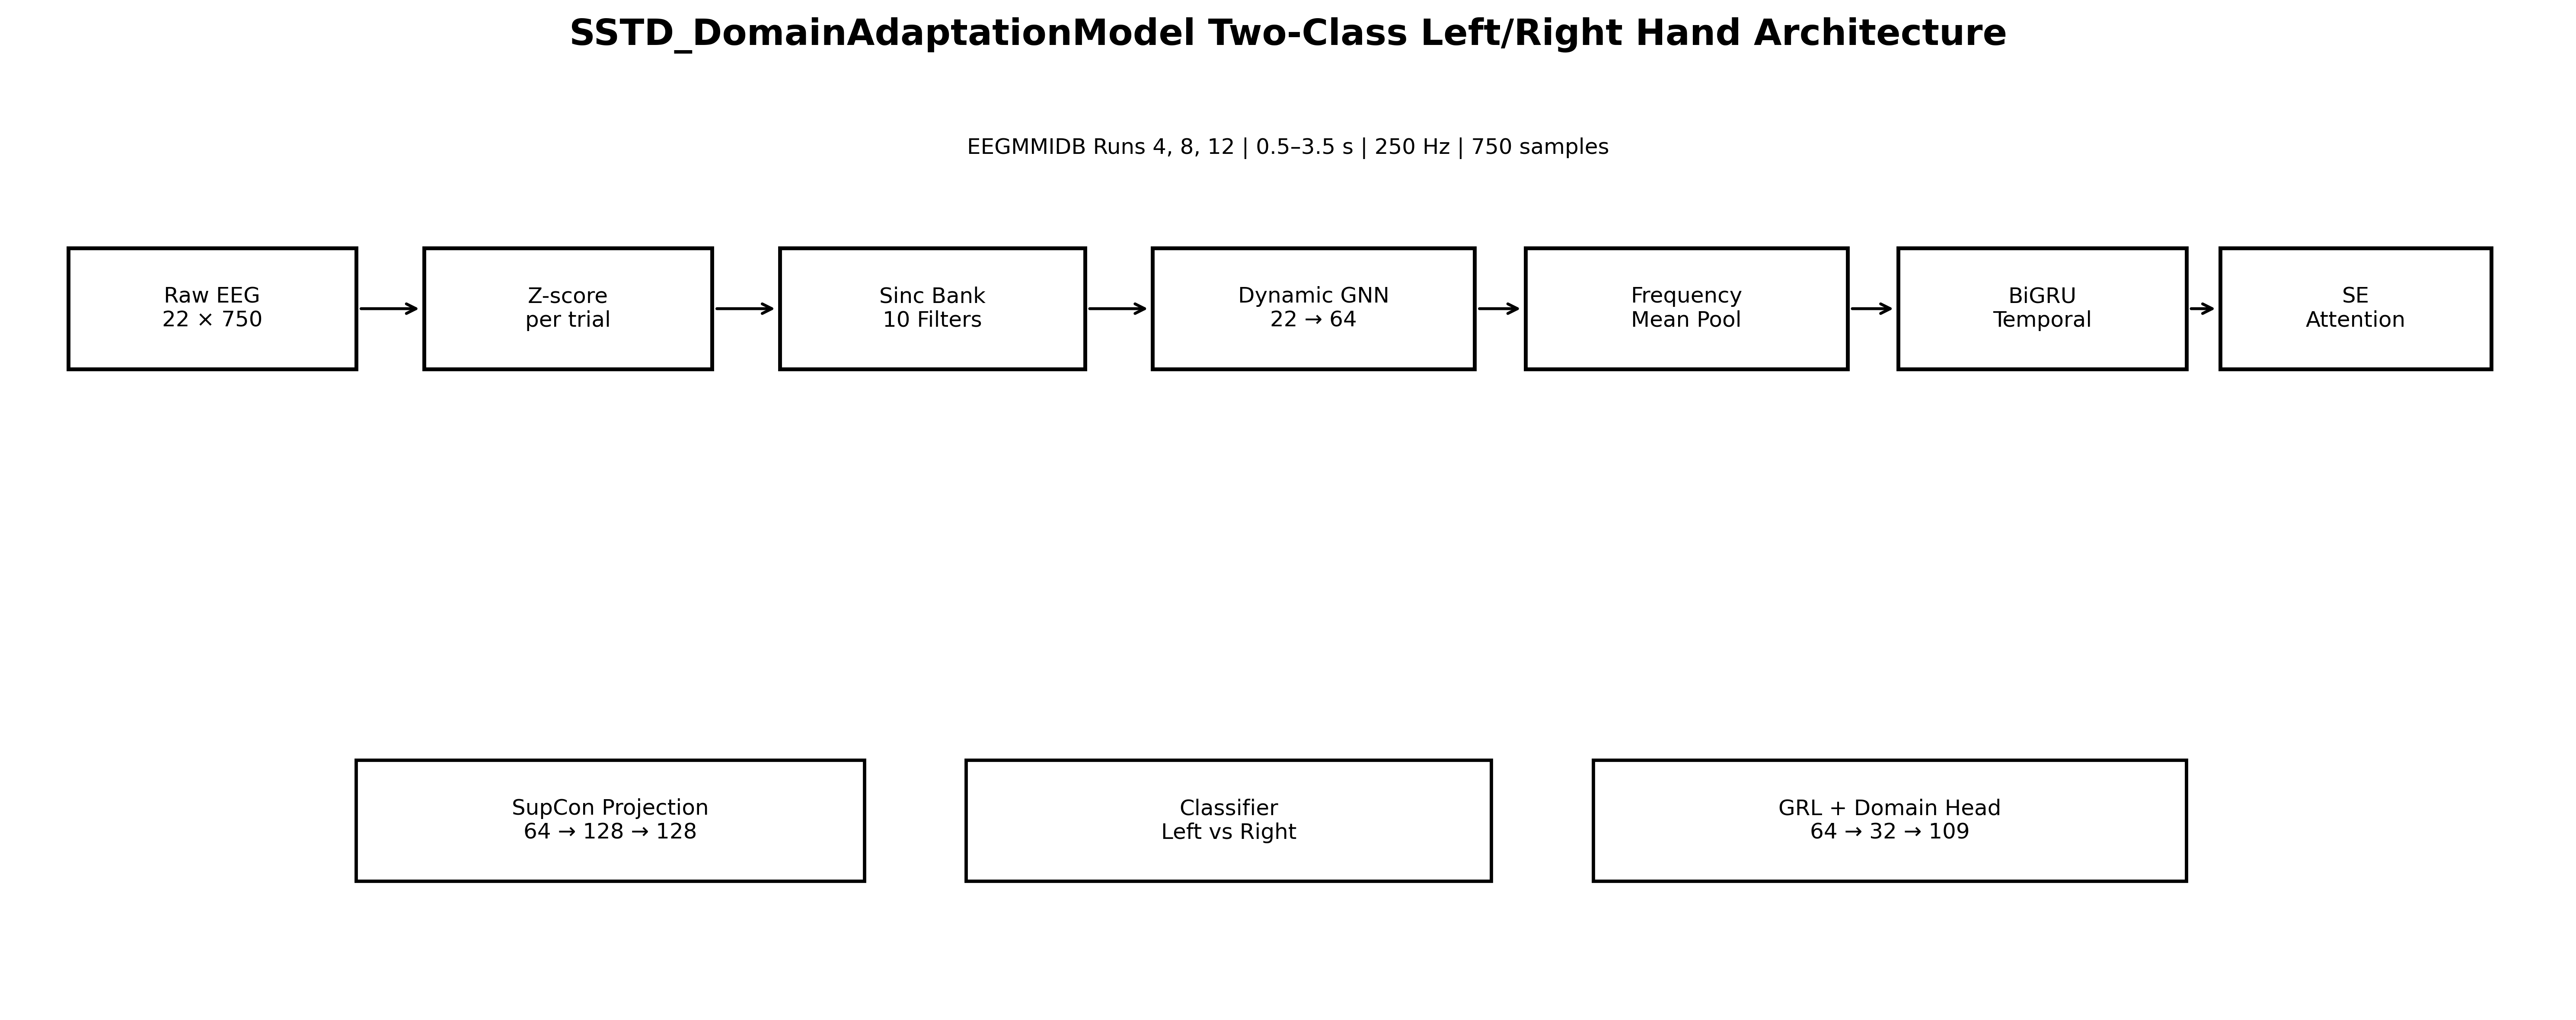

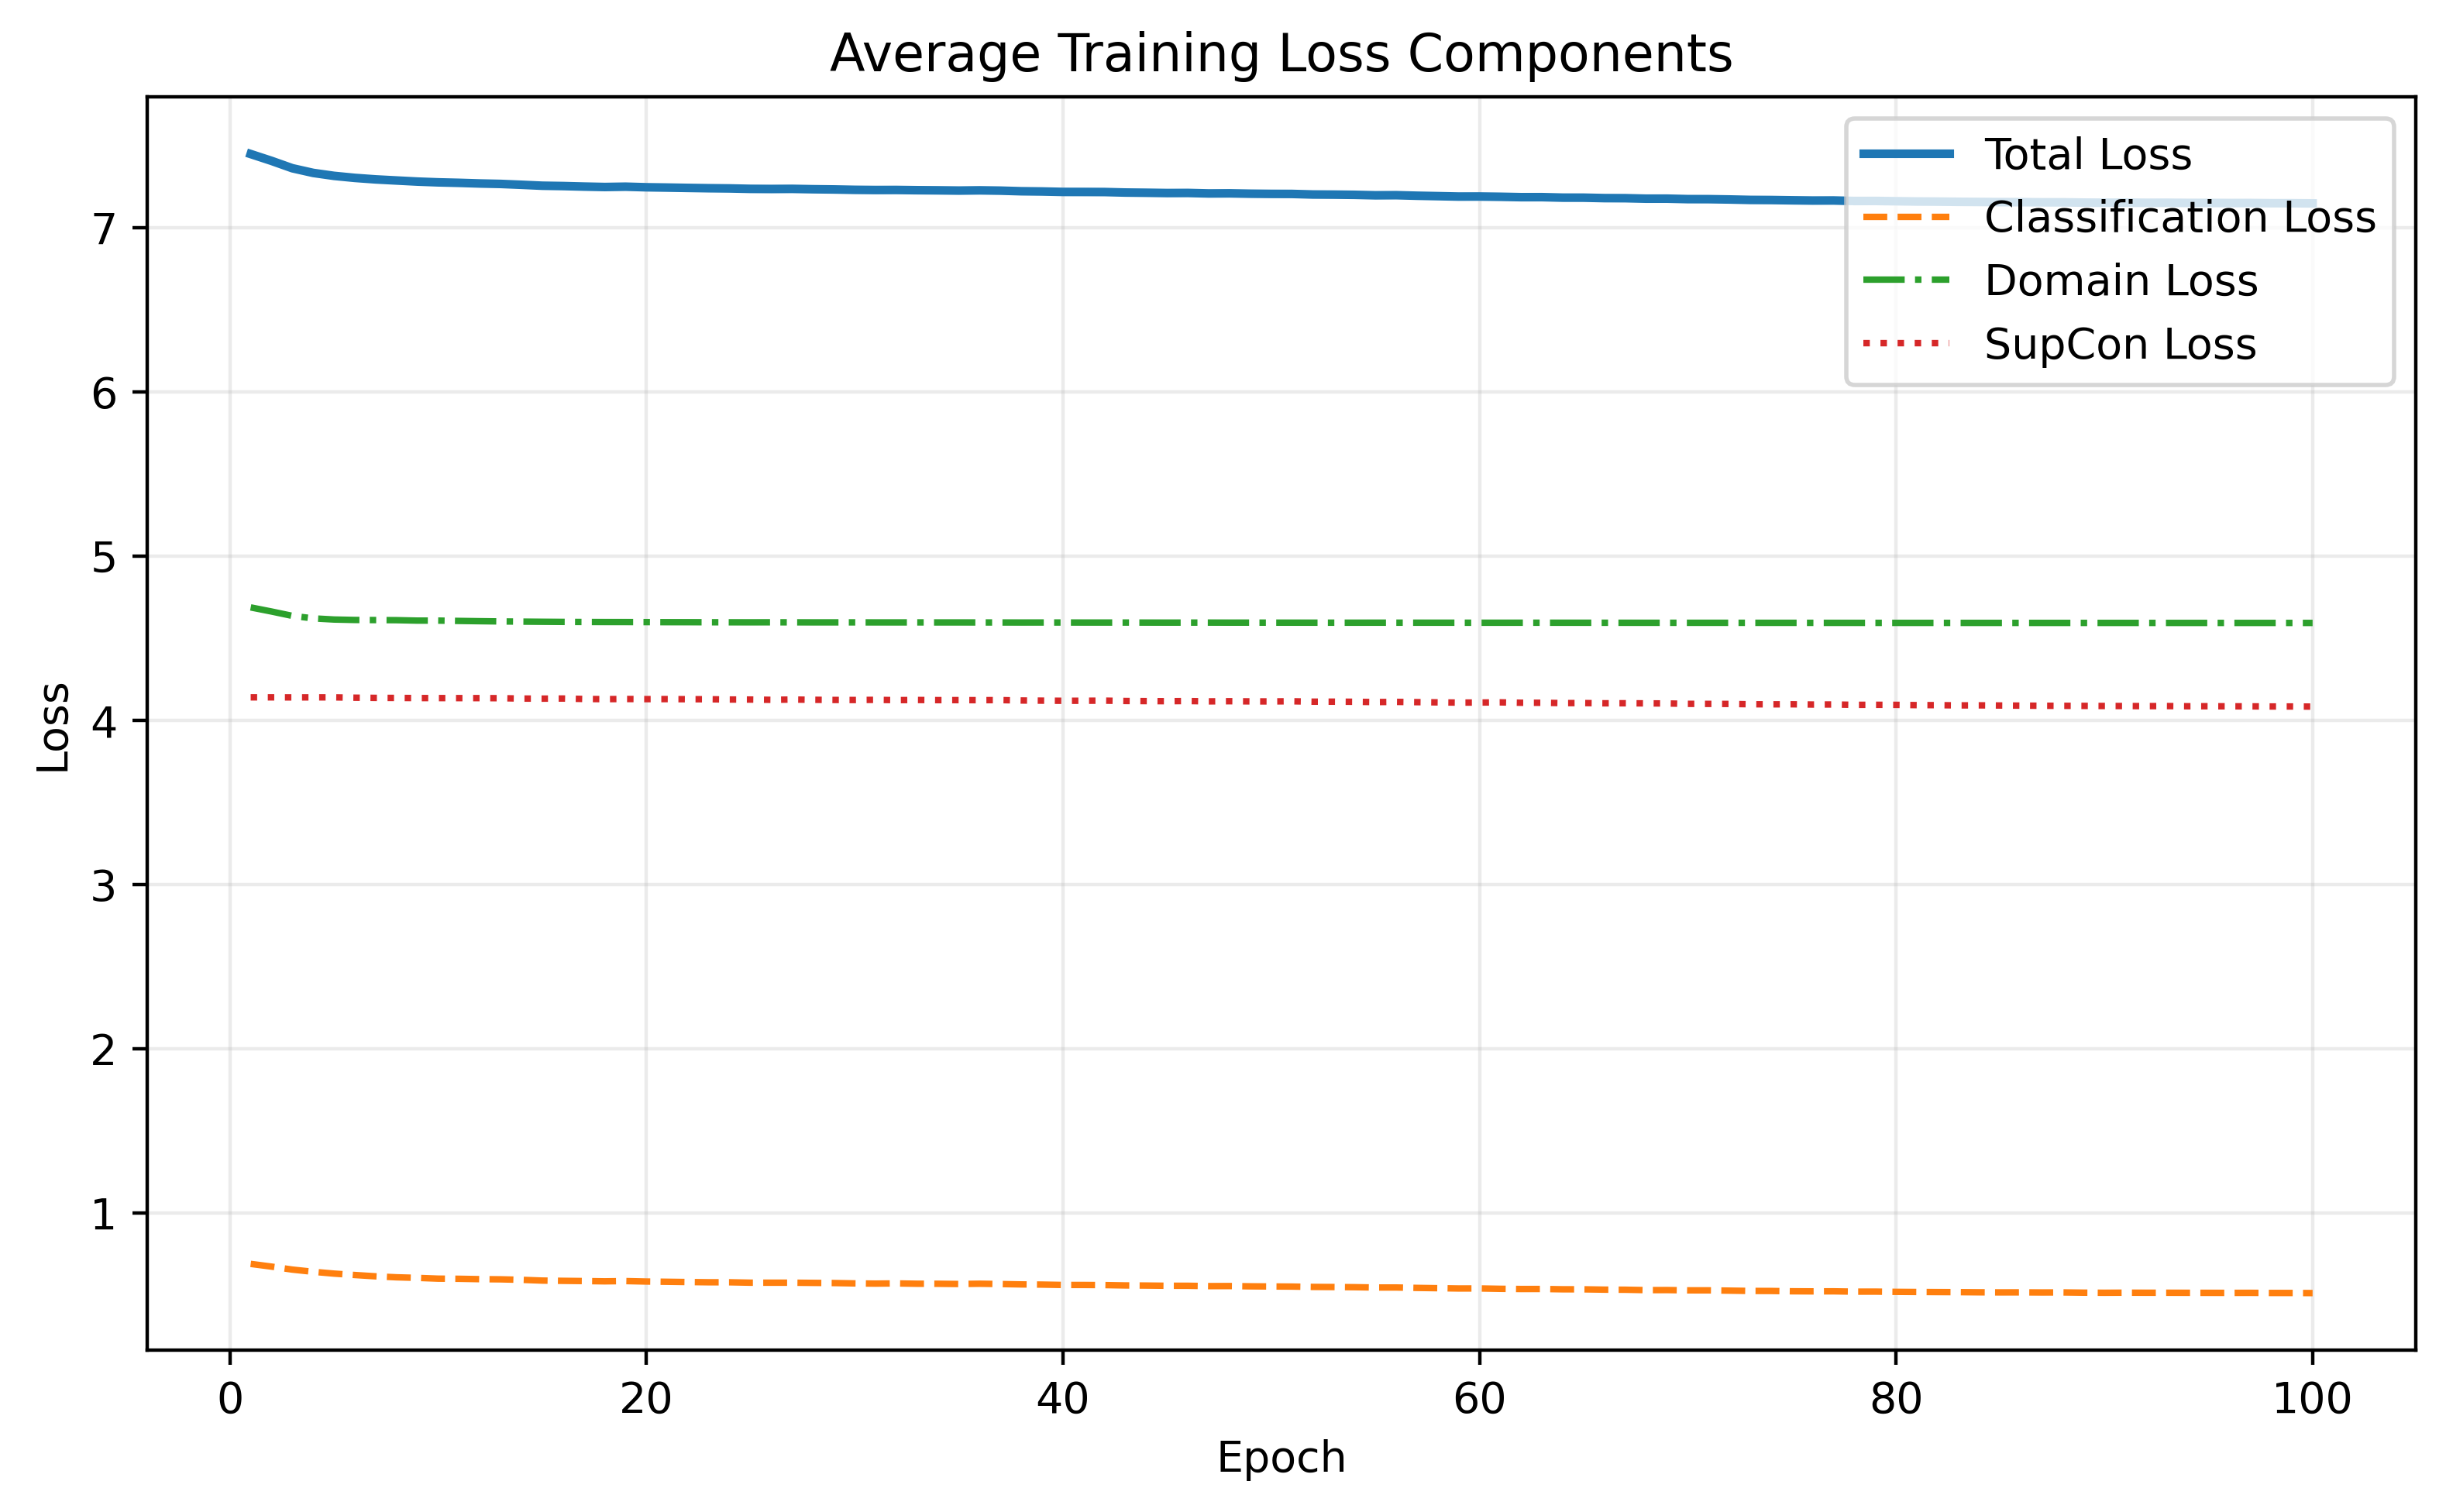

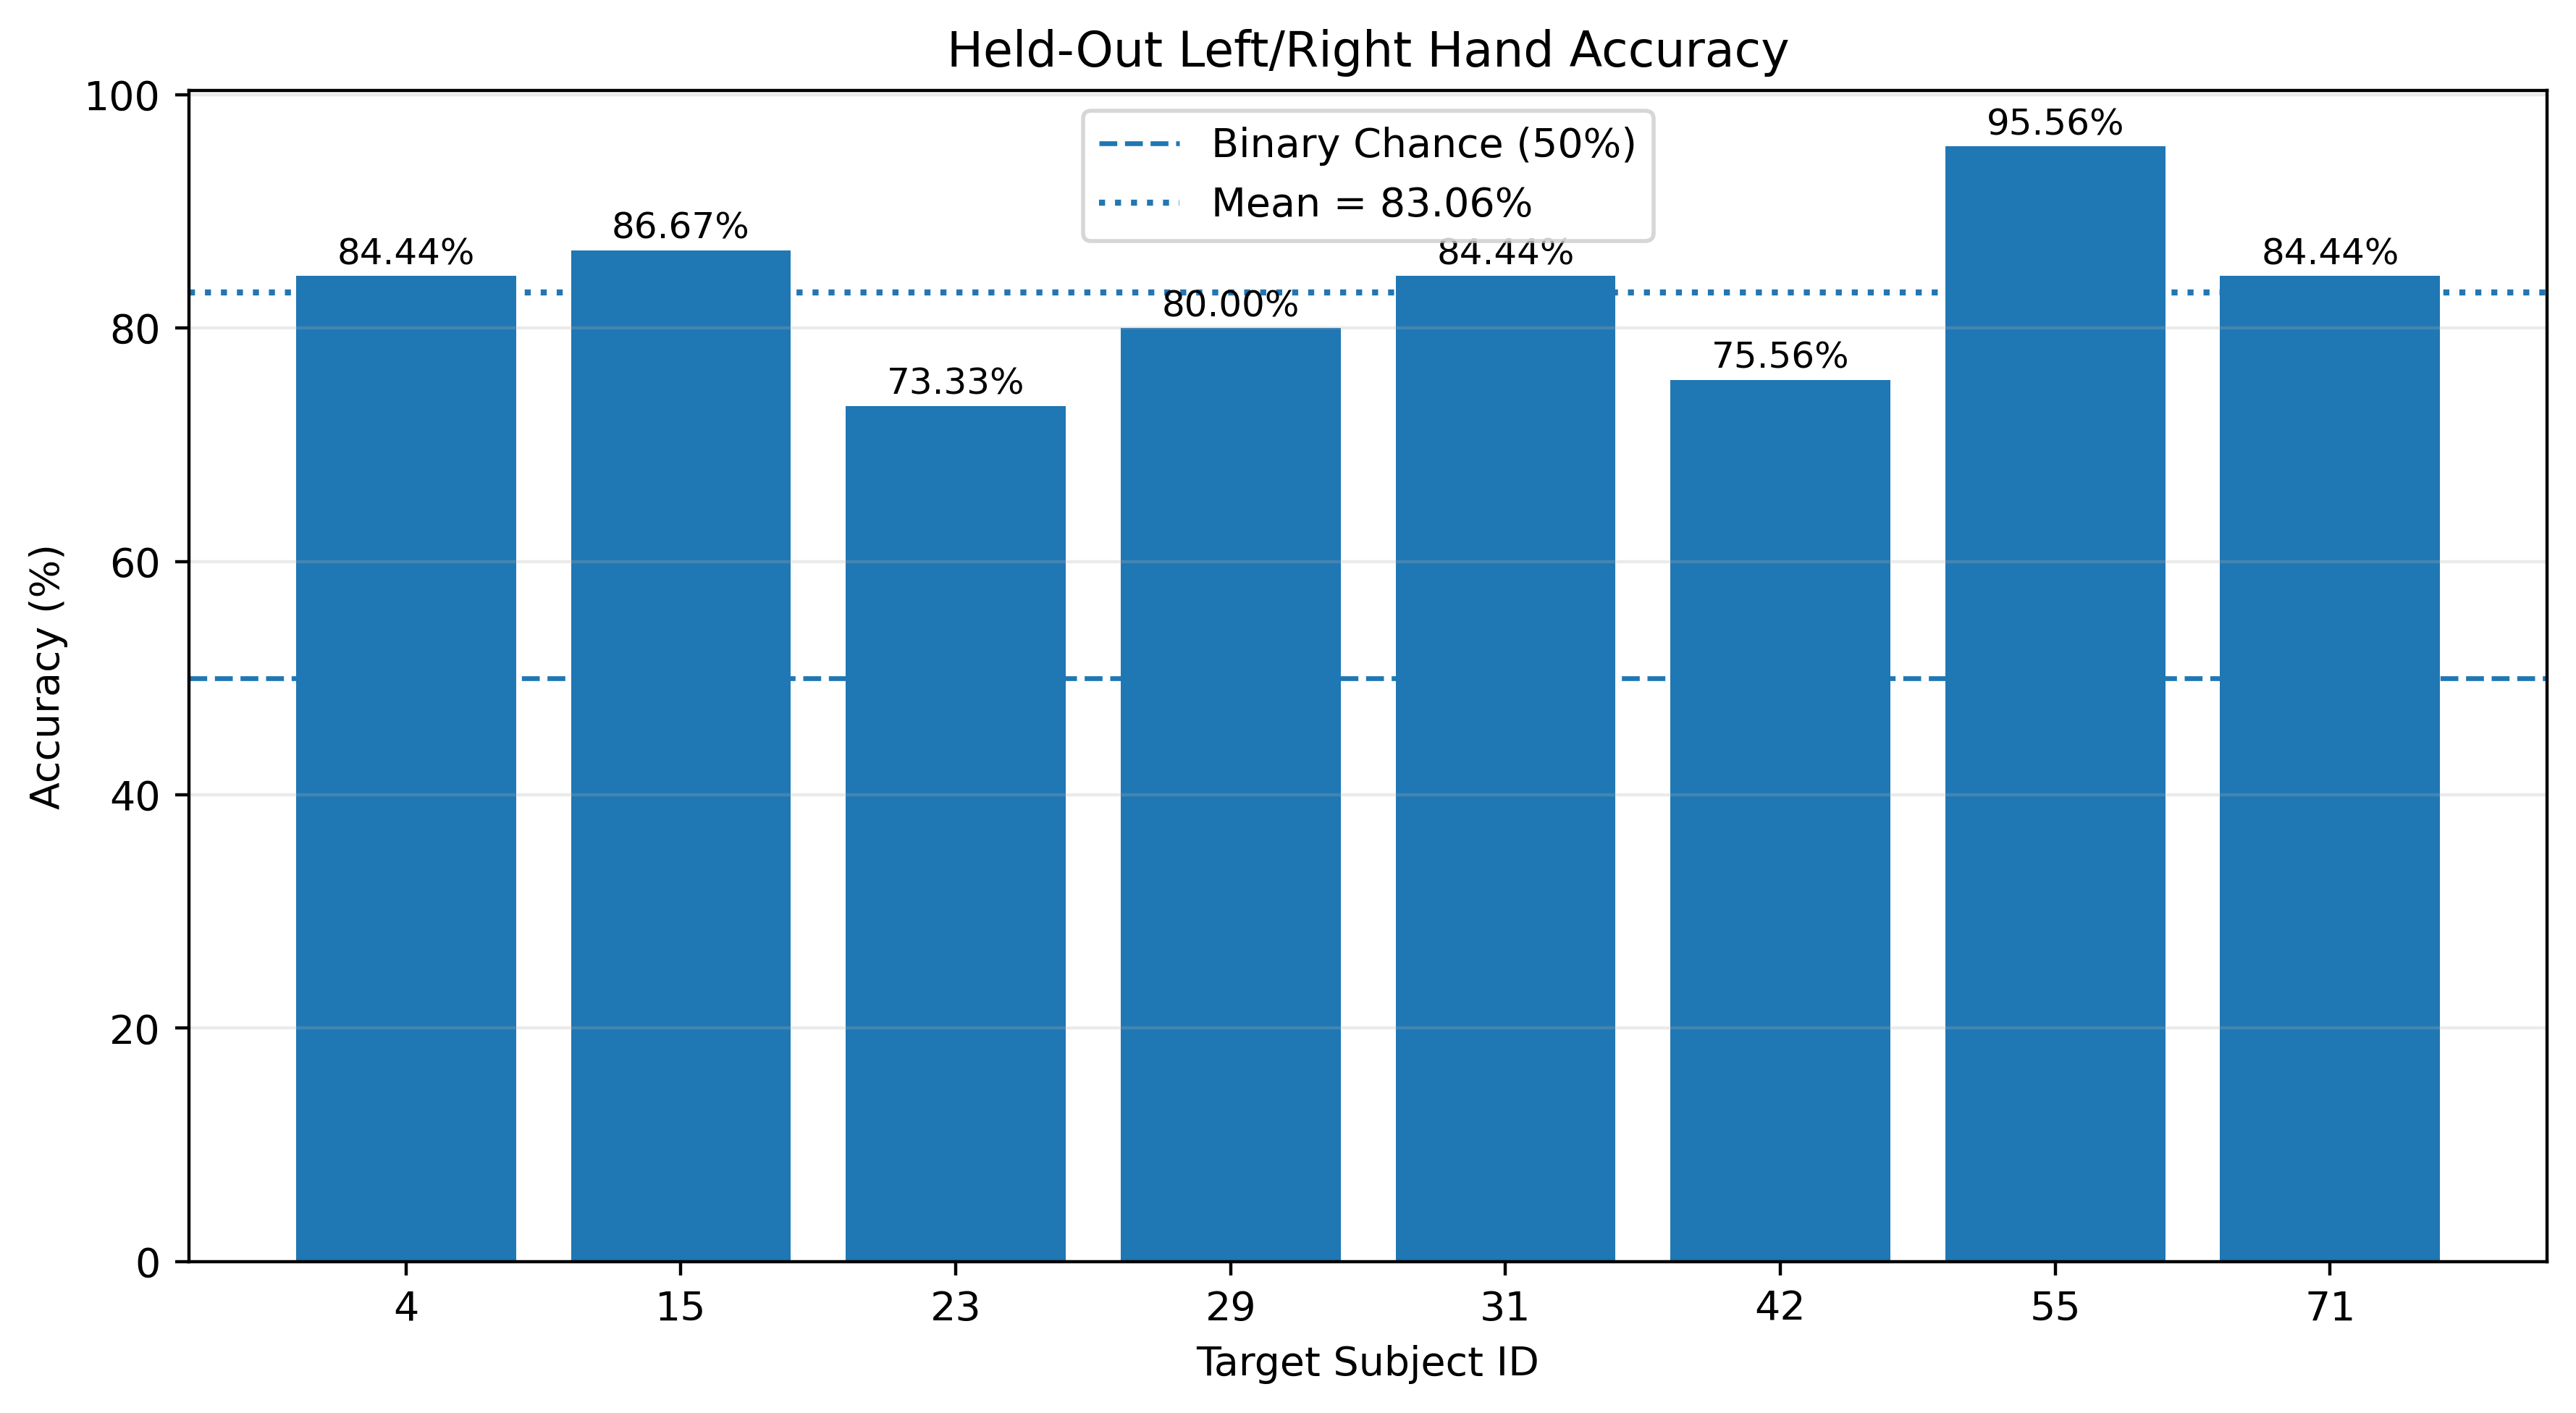

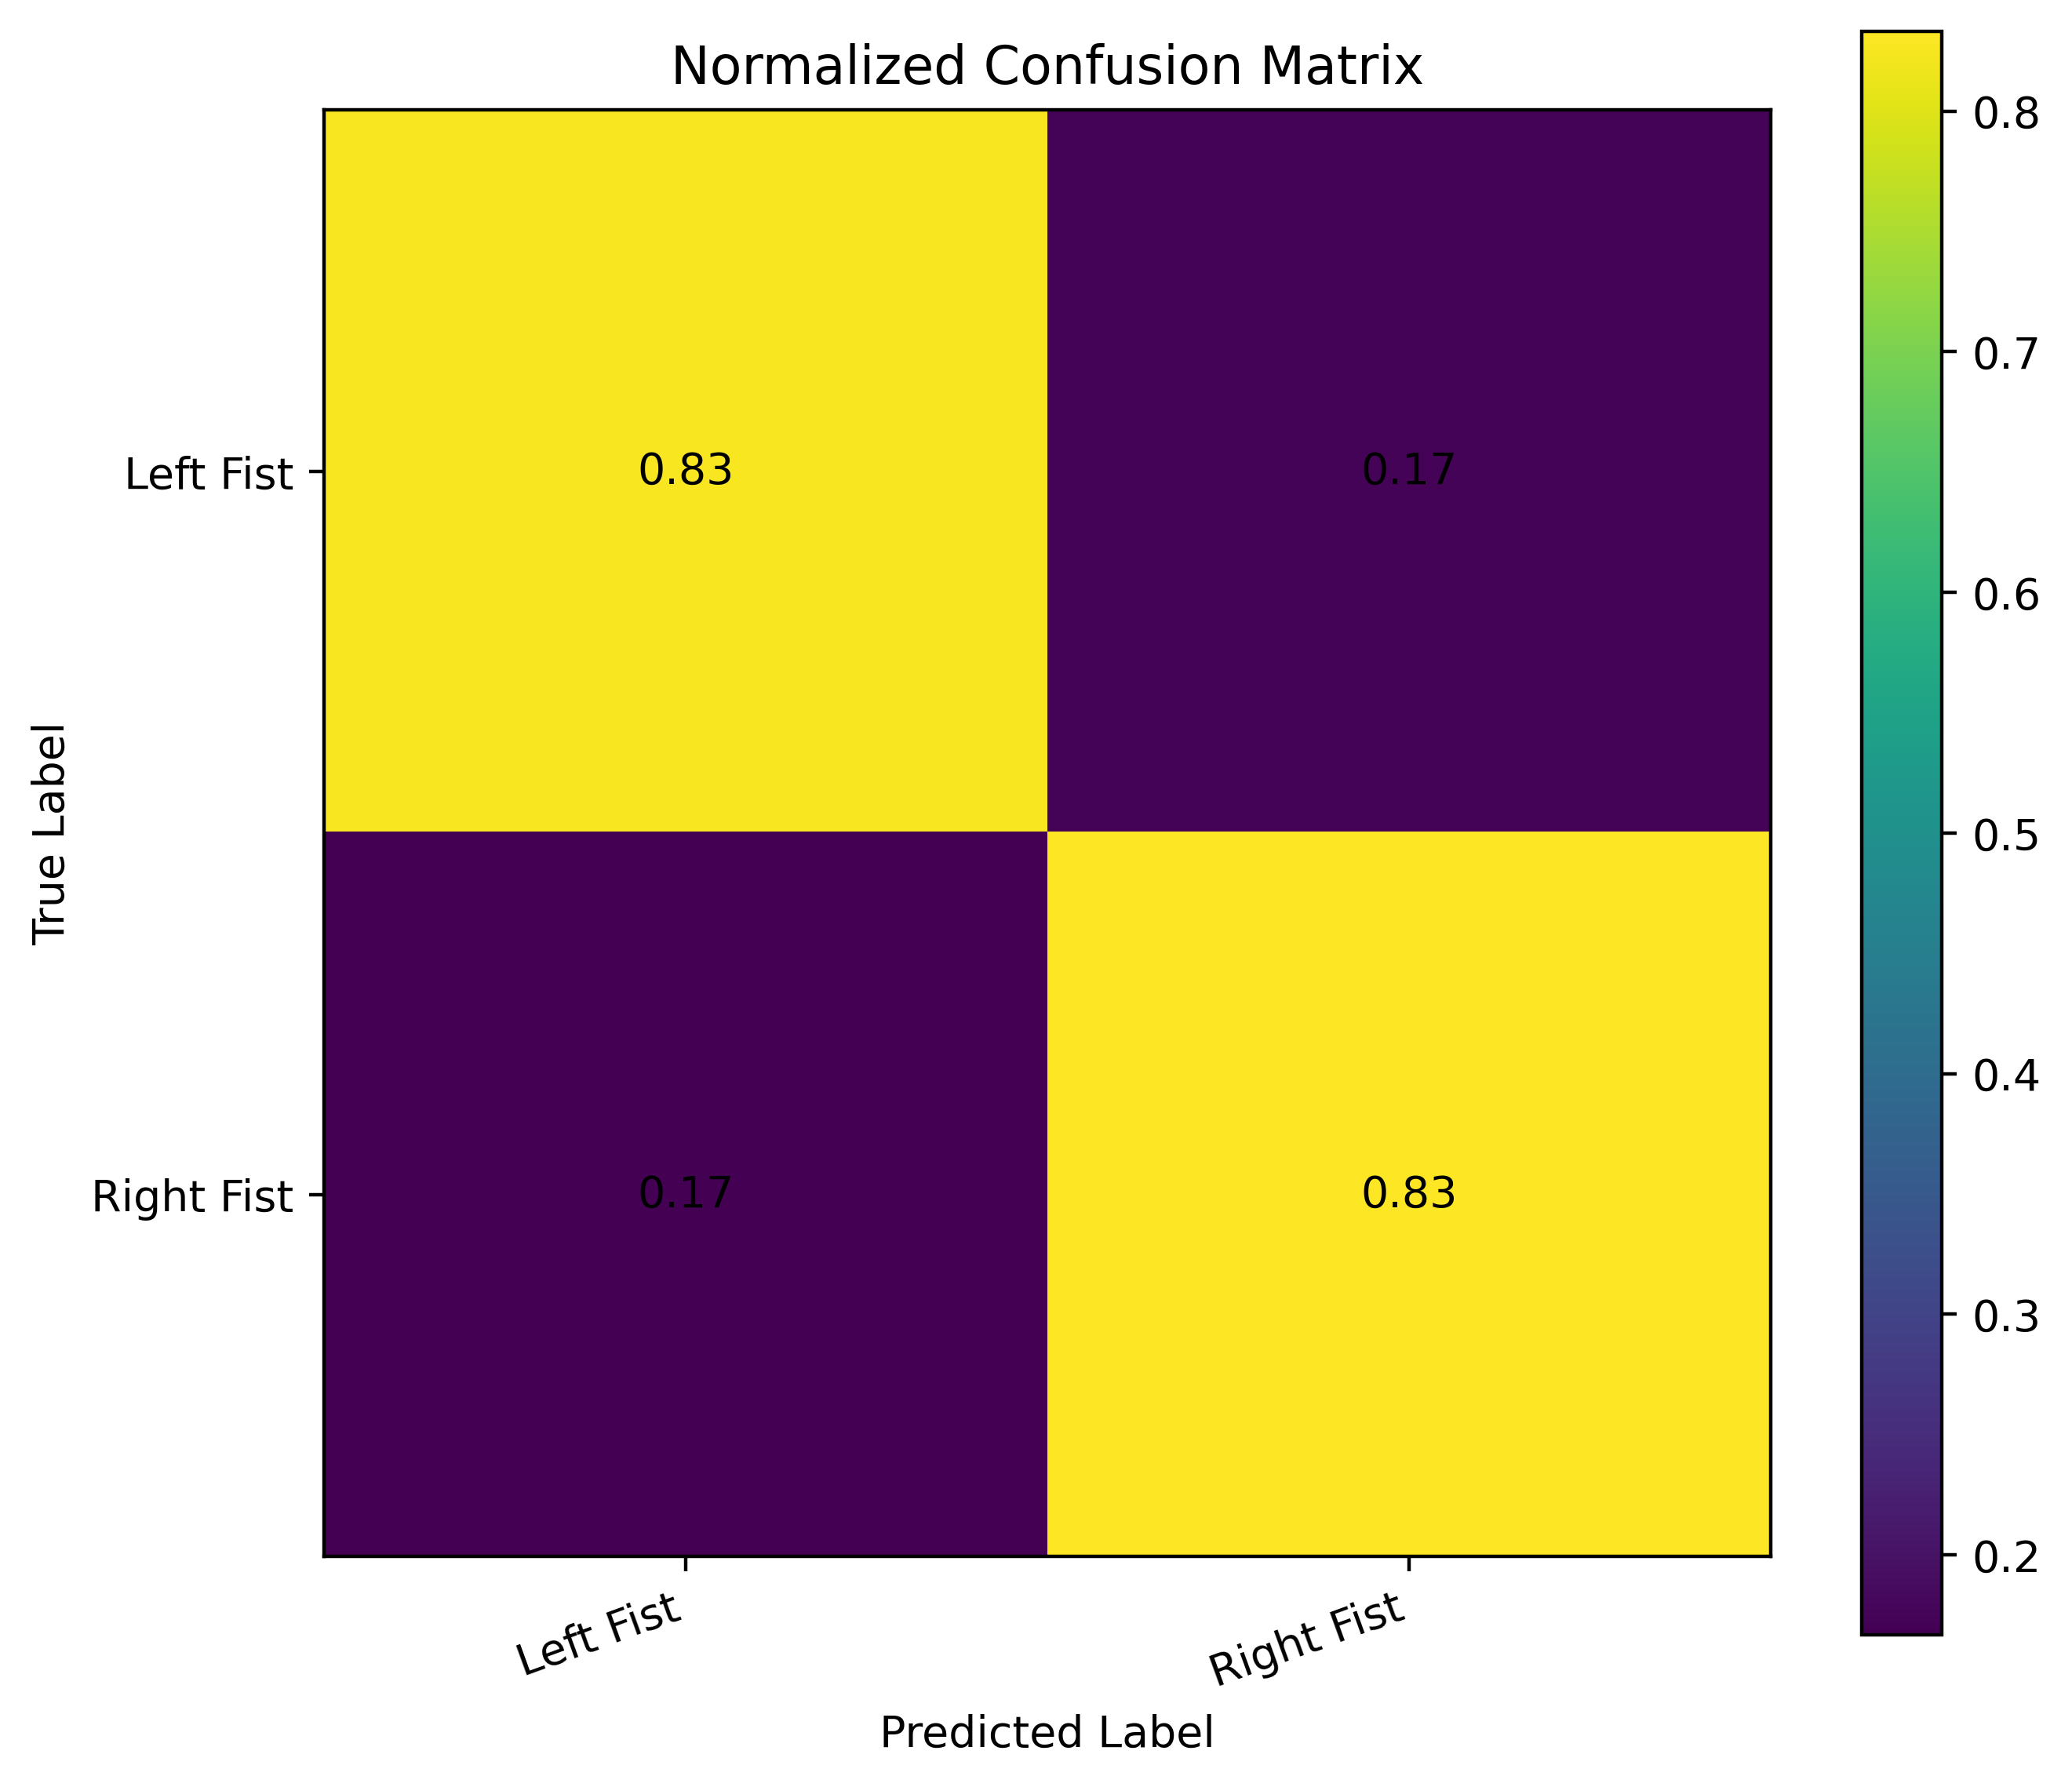

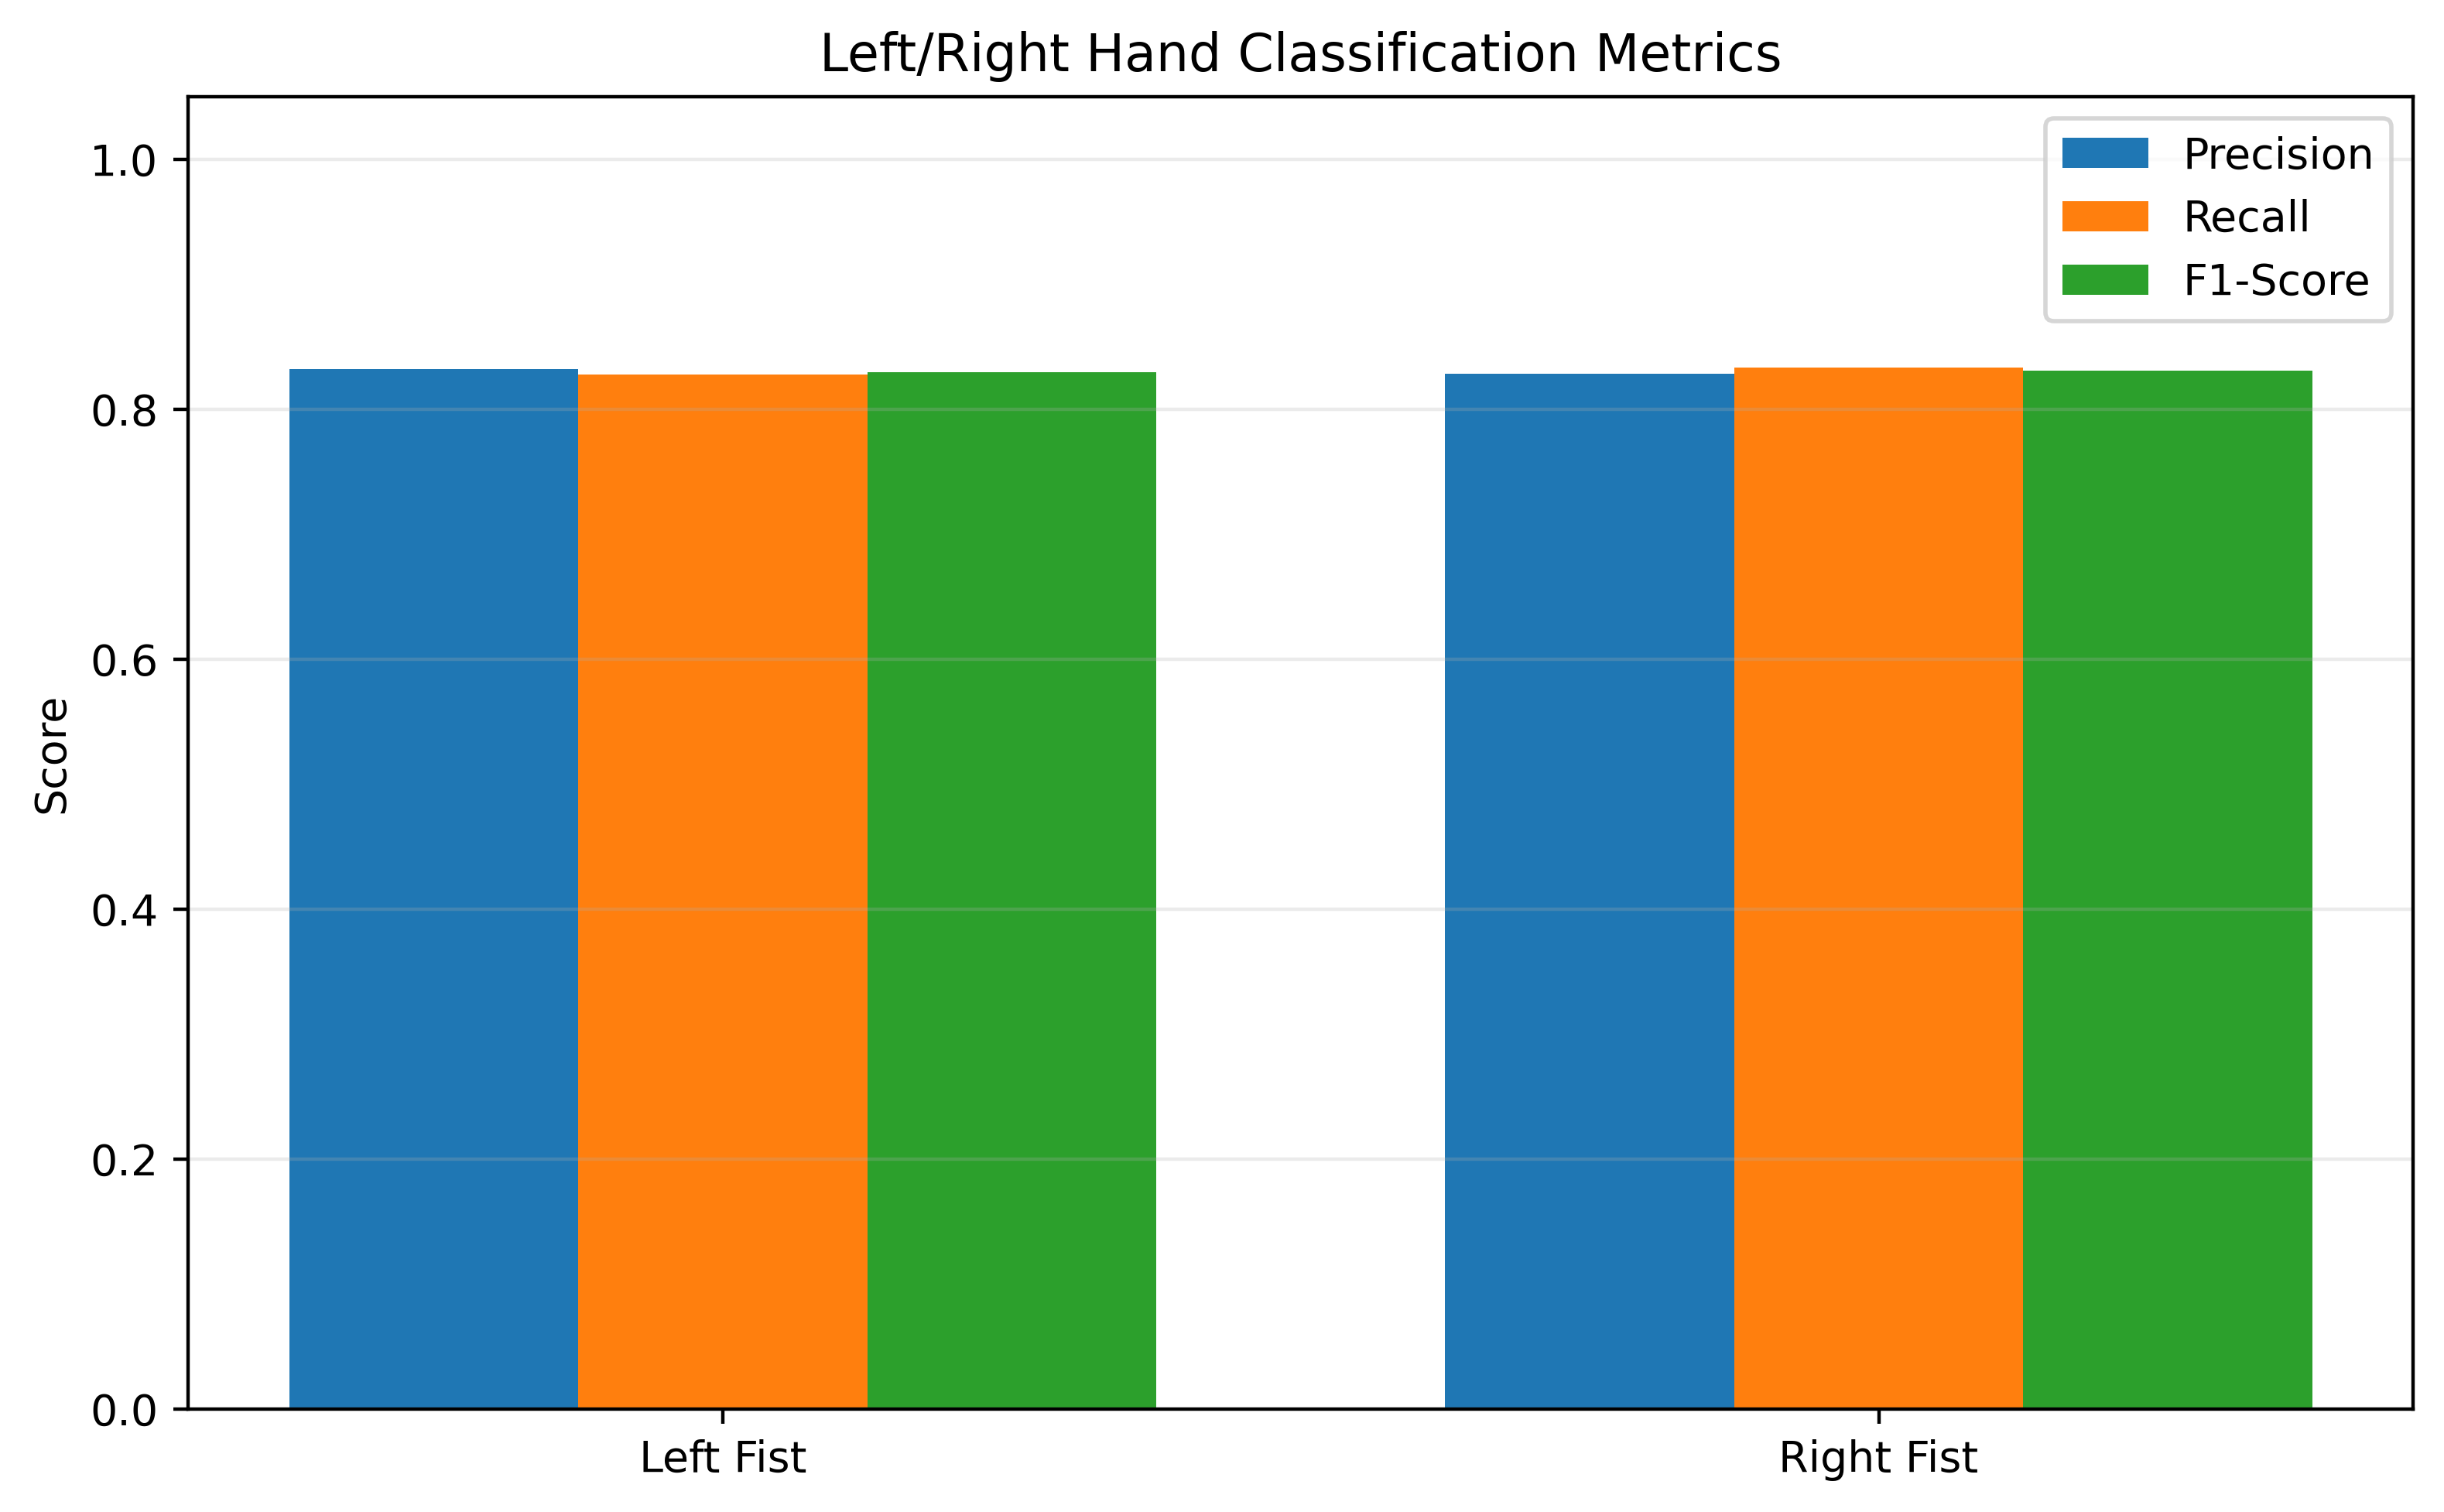

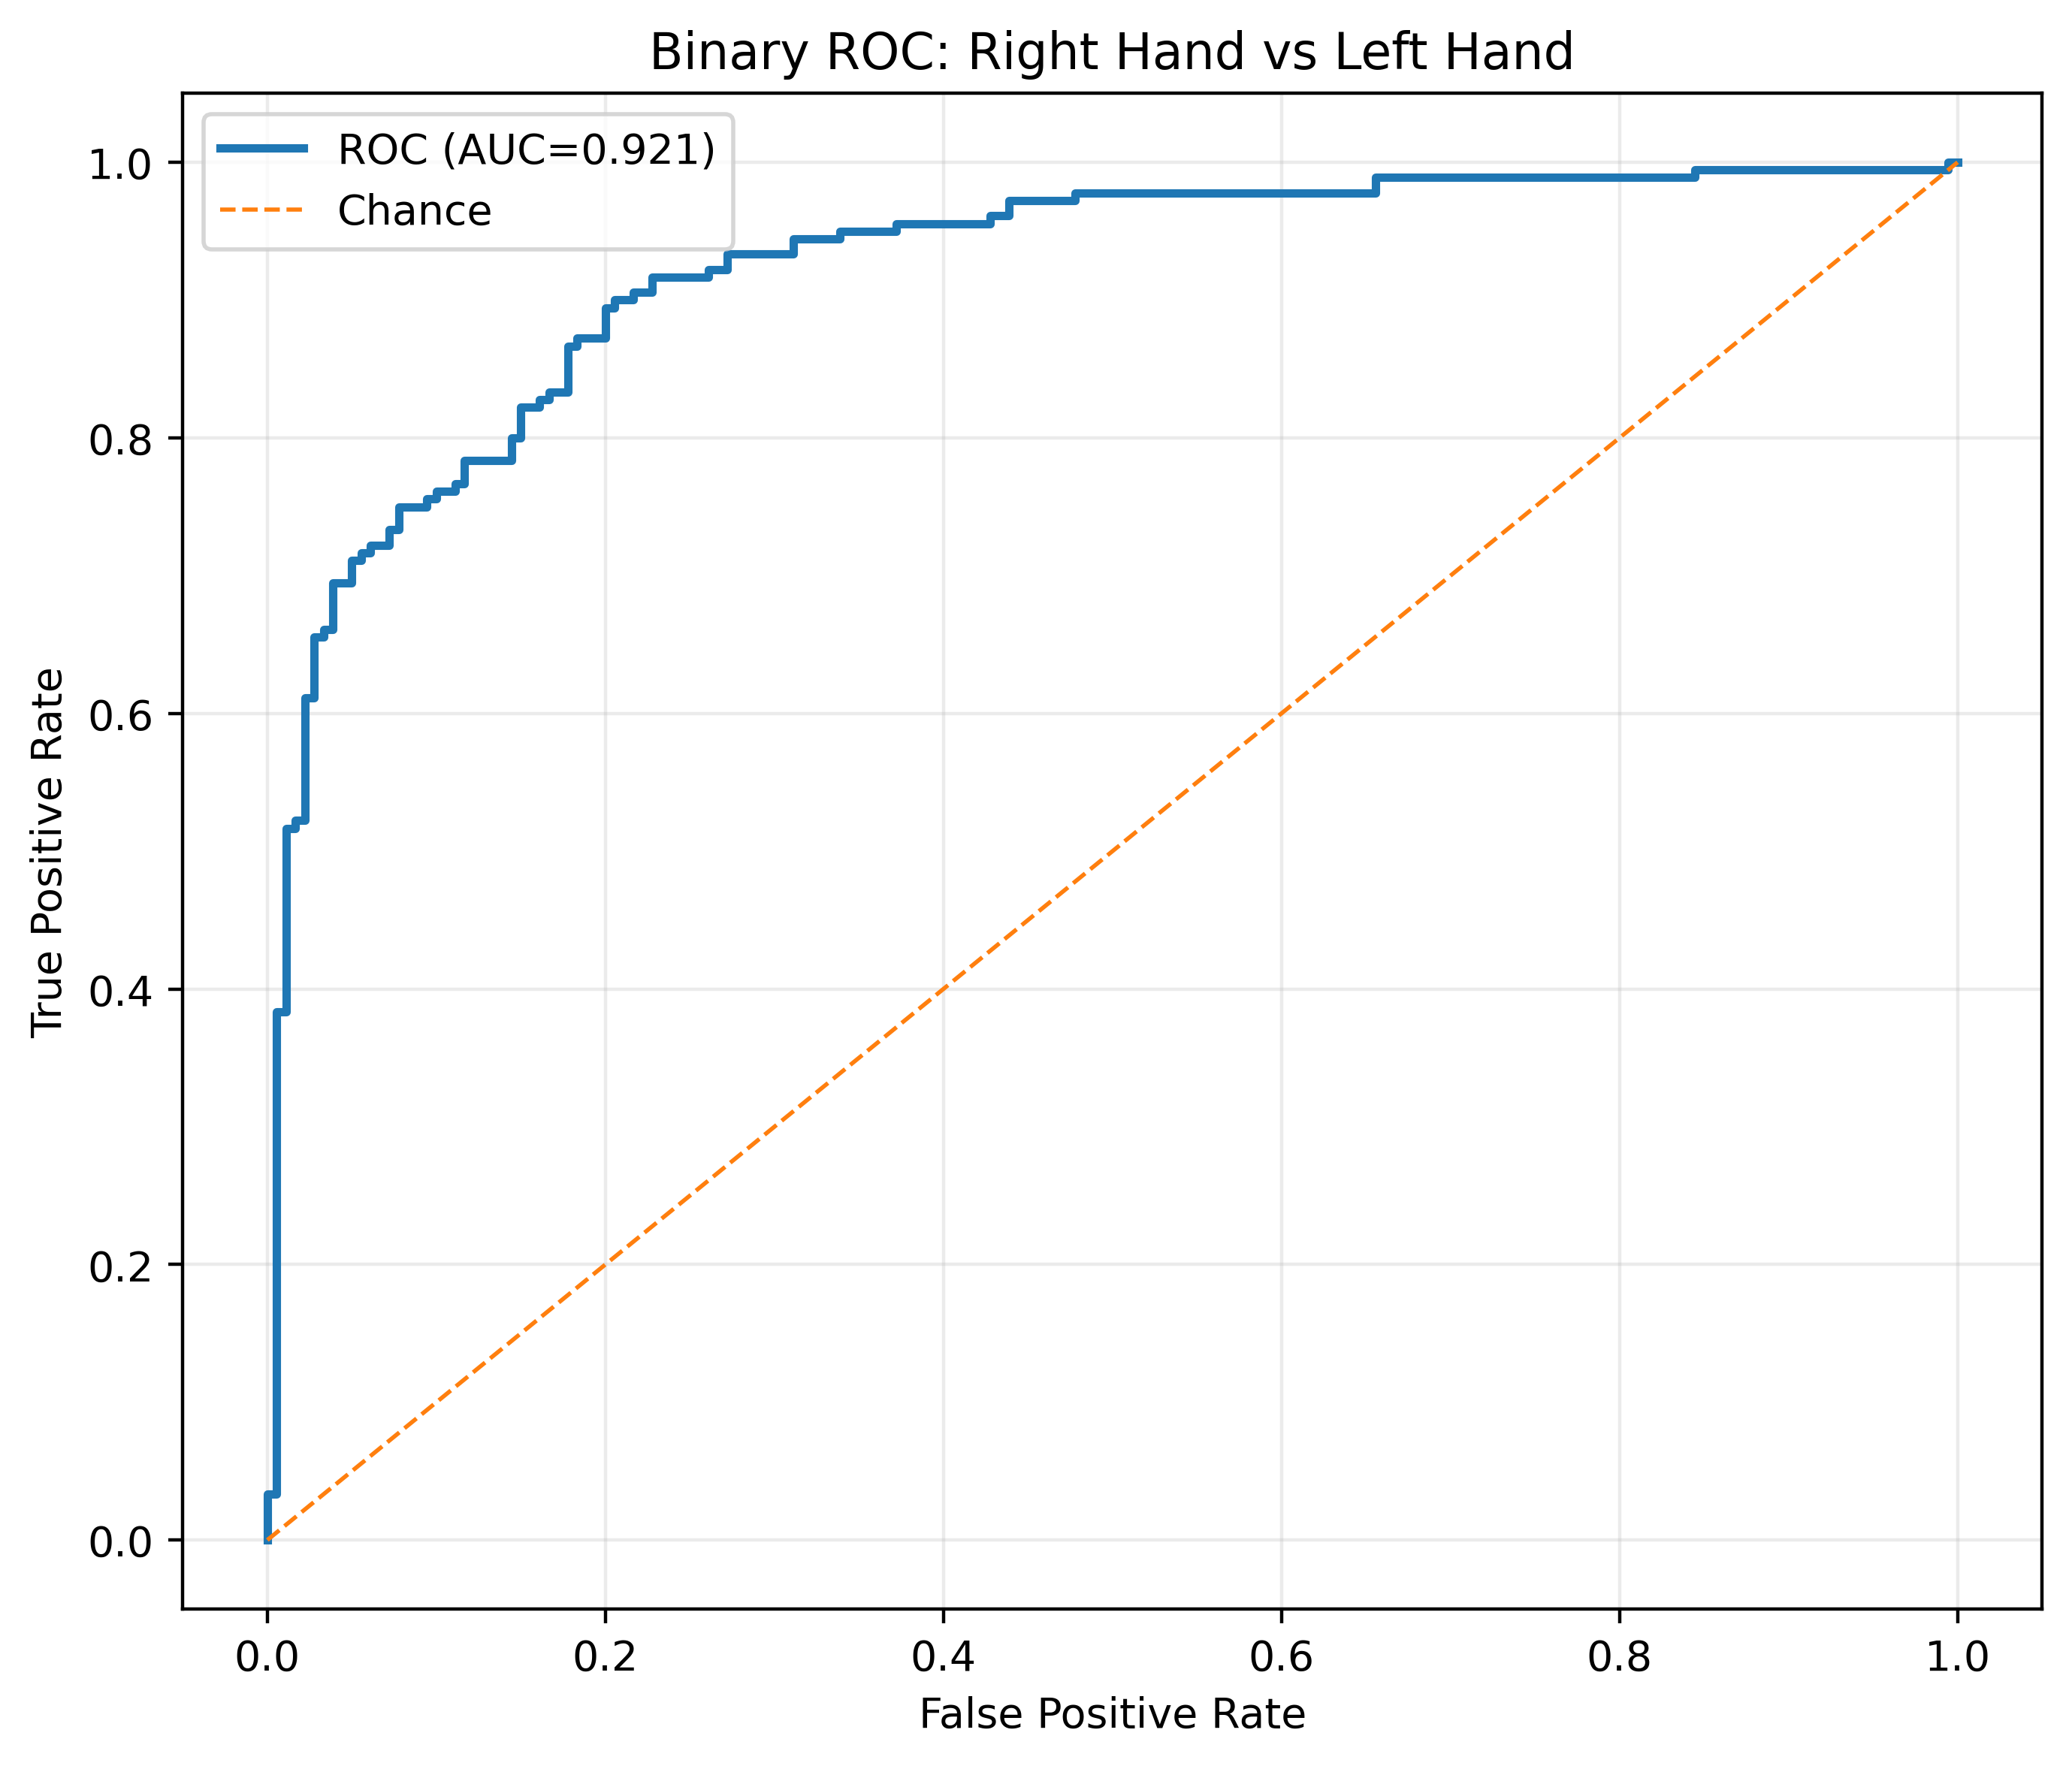

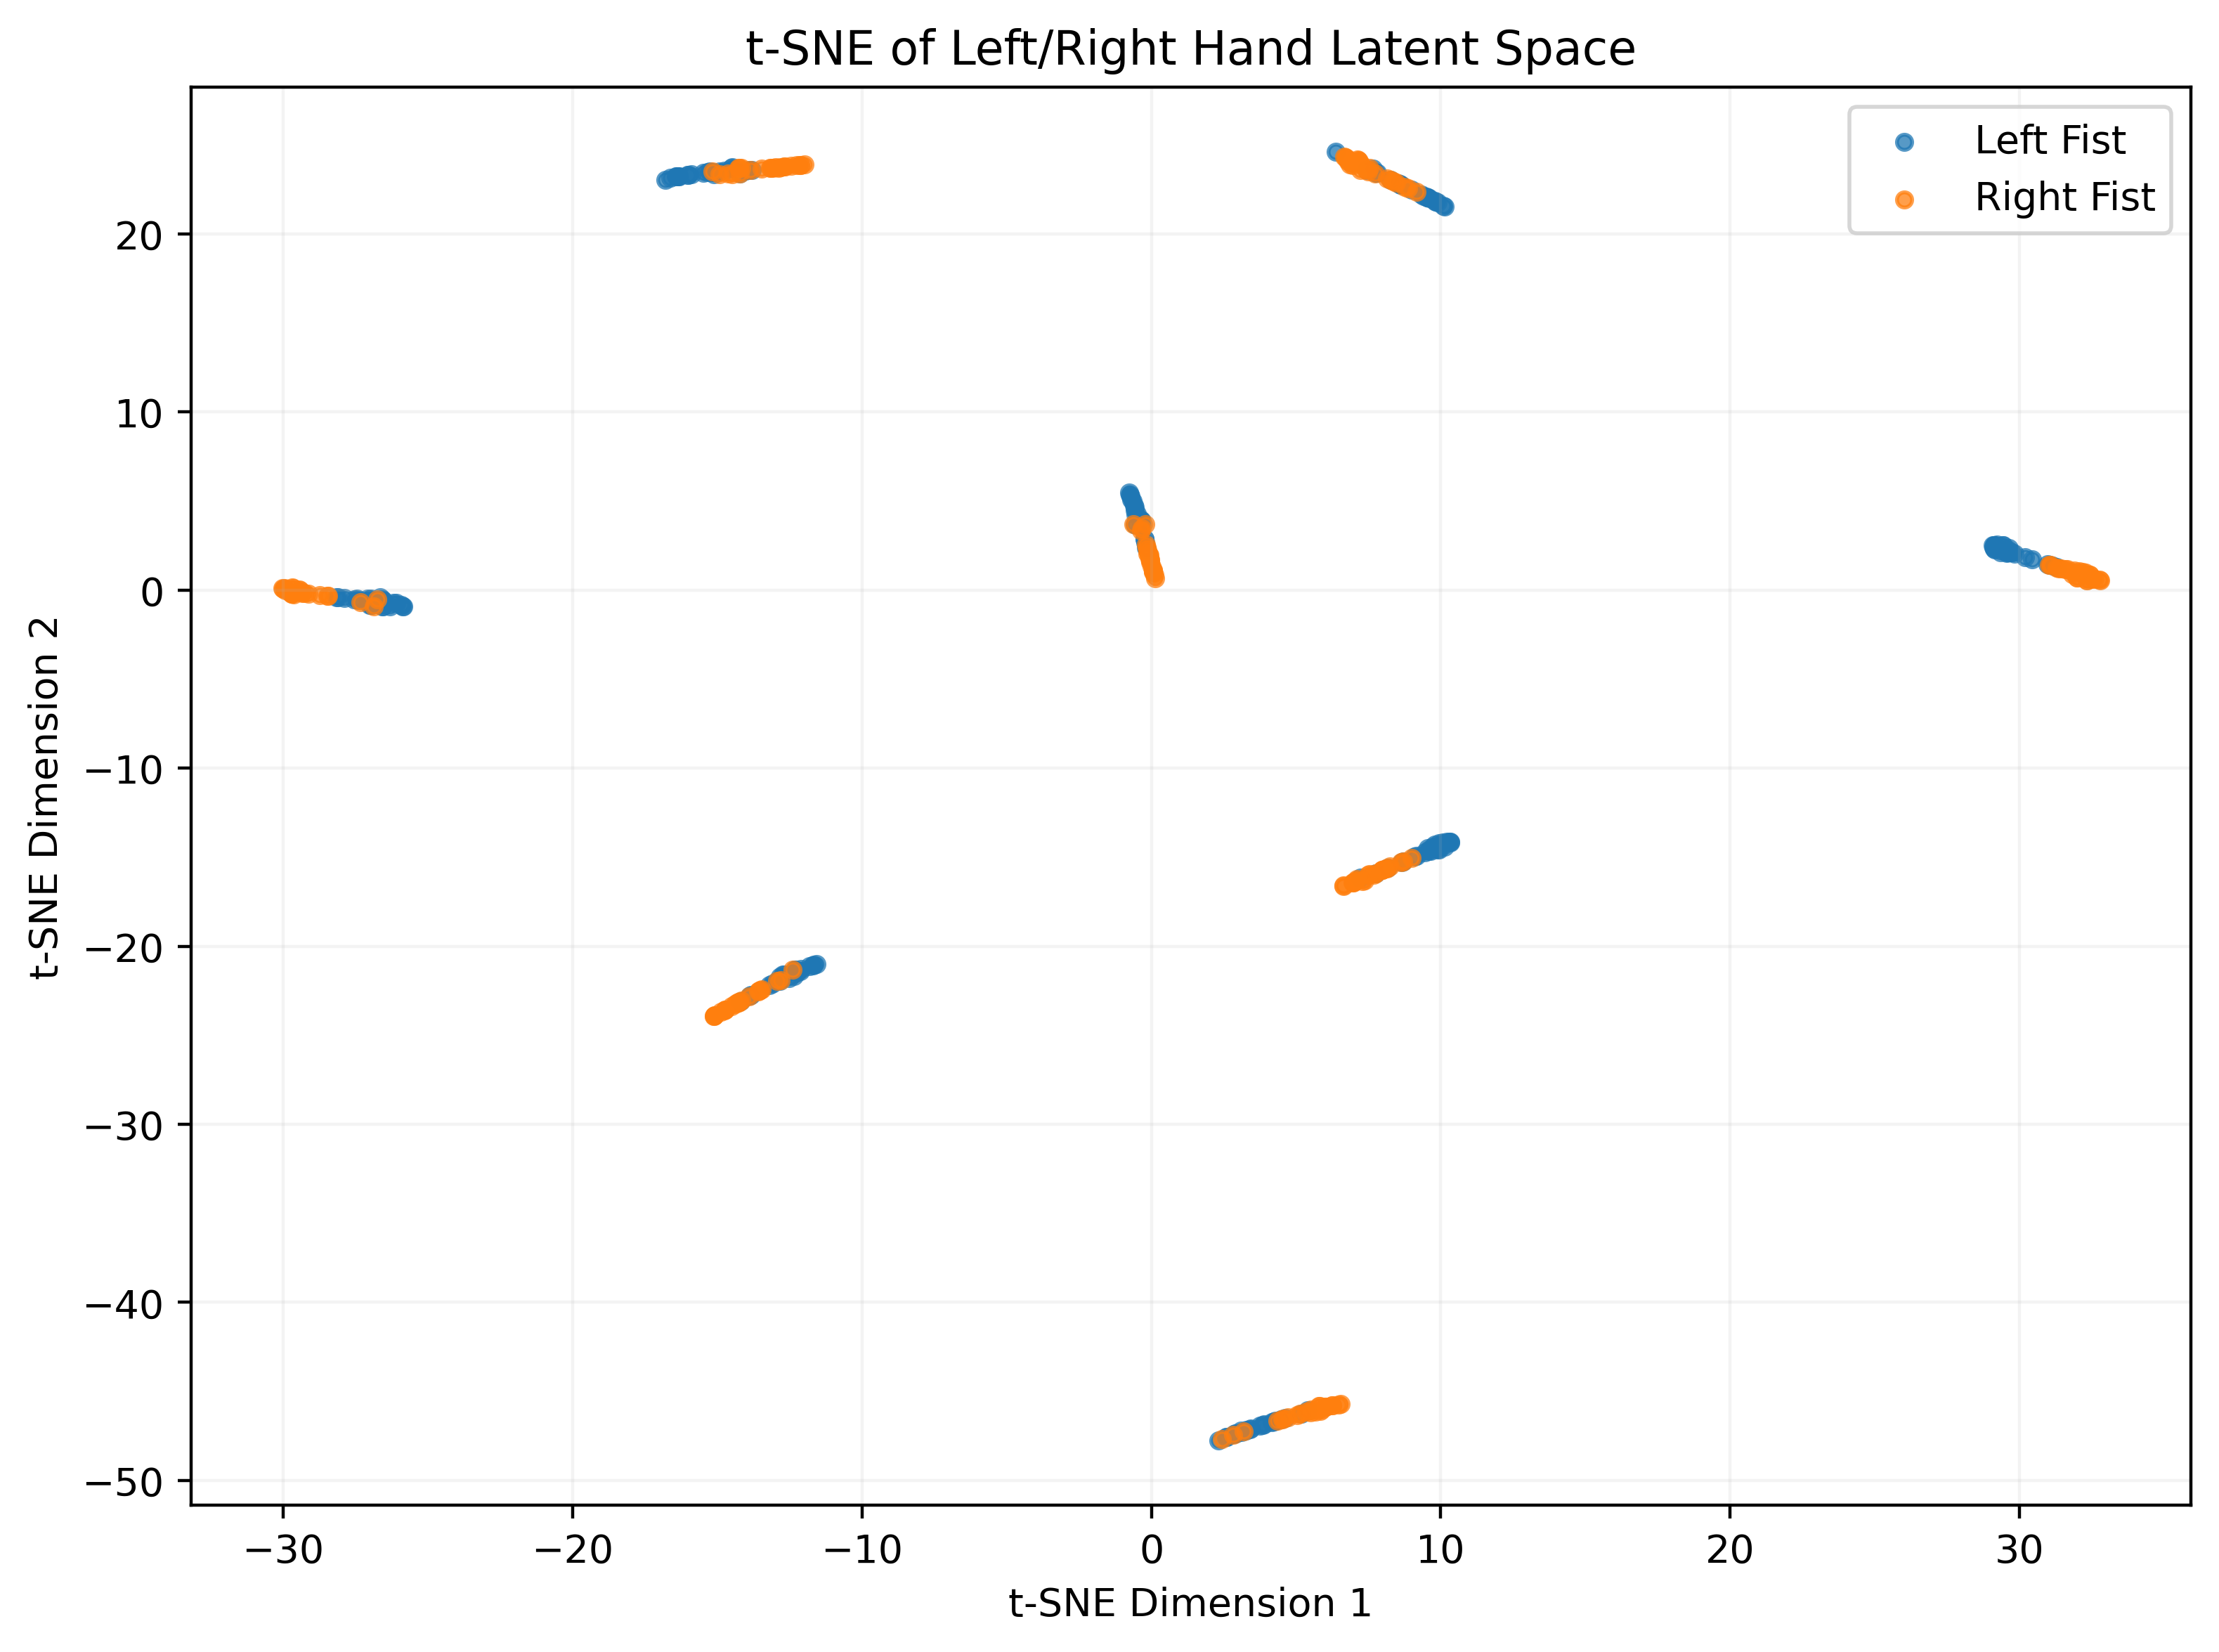


Displayed 7 available figure(s) from:
/Users/ashokvarmabevara/Project2/results_sstd_da_2class/figures


In [43]:

from IPython.display import display, Image
from pathlib import Path

figure_files = [
    "Fig1_Architecture_2Class.png",
    "Fig2_TrainingLoss_2Class.png",
    "Fig3_FoldAccuracy_2Class.png",
    "Fig4_ConfusionMatrix_2Class.png",
    "Fig5_ClassMetrics_2Class.png",
    "Fig6_ROC_AUC_2Class.png",
    "Fig7_tSNE_2Class.png",
]

available_figures = []
for name in figure_files:
    path = FIG_DIR / name
    if path.exists():
        available_figures.append(path)
        display(Image(filename=str(path)))

print(f"\nDisplayed {len(available_figures)} available figure(s) from:")
print(FIG_DIR.resolve())


## Clean implementation note

The legacy `S3MambaDA` and `SimplifiedBiMamba` identifiers are intentionally absent from this notebook. The temporal block is named and documented directly as **Bidirectional GRU**, matching the actual `nn.GRU(..., bidirectional=True)` implementation.

No diffusion augmentation or Mamba state-space module is introduced by this cleanup.



SSTD COMPONENT IMPORTANCE ANALYSIS

Target subject : S055
Device         : mps
Epochs         : 100

Source subjects: 99
Target subjects: S055

Loading subjects: [25, 56, 105, 48, 103, 7, 75, 3, 73, 6, 102, 97, 35, 106, 4, 10, 83, 58, 62, 88, 15, 41, 32, 40, 24, 33, 53, 70, 109, 23, 14, 31, 74, 71, 17, 9, 18, 79, 77, 82, 36, 11, 8, 59, 94, 64, 51, 16, 12, 2, 38, 65, 84, 13, 85, 100, 45, 66, 91, 1, 92, 52, 49, 96, 87, 46, 63, 57, 78, 60, 95, 69, 29, 28, 104, 99, 43, 27, 98, 39, 101, 22, 20, 30, 81, 19, 67, 54, 72, 26, 61, 93, 89, 37, 47, 21, 107, 80, 5]
[OK] S025R04 | T1=7 | T2=8 | Epochs=15
[OK] S025R08 | T1=7 | T2=8 | Epochs=15
[OK] S025R12 | T1=8 | T2=7 | Epochs=15
[OK] S056R04 | T1=7 | T2=8 | Epochs=15
[OK] S056R08 | T1=7 | T2=8 | Epochs=15
[OK] S056R12 | T1=8 | T2=7 | Epochs=15
[OK] S105R04 | T1=8 | T2=7 | Epochs=15
[OK] S105R08 | T1=7 | T2=8 | Epochs=15
[OK] S105R12 | T1=8 | T2=7 | Epochs=15
[OK] S048R04 | T1=8 | T2=7 | Epochs=15
[OK] S048R08 | T1=7 | T2=8 | Epochs=15
[OK] S048R1

,Rank,Component,Baseline Accuracy (%),Ablated Accuracy (%),Accuracy Drop (pp),Relative Drop (%),Normalized Sensitivity (%)
0,1,Dynamic GNN,86.666667,48.888889,37.777778,43.589744,26.153846
1,2,Sinc Filter,86.666667,51.111111,35.555556,41.025641,24.615385
2,3,BiGRU,86.666667,51.111111,35.555556,41.025641,24.615385
3,4,SE Attention,86.666667,51.111111,35.555556,41.025641,24.615385


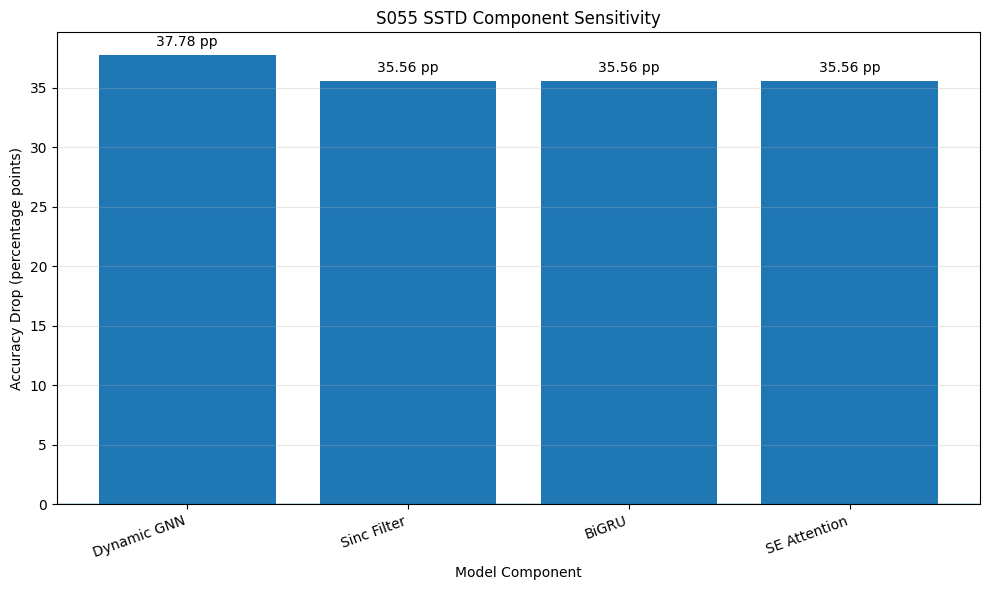

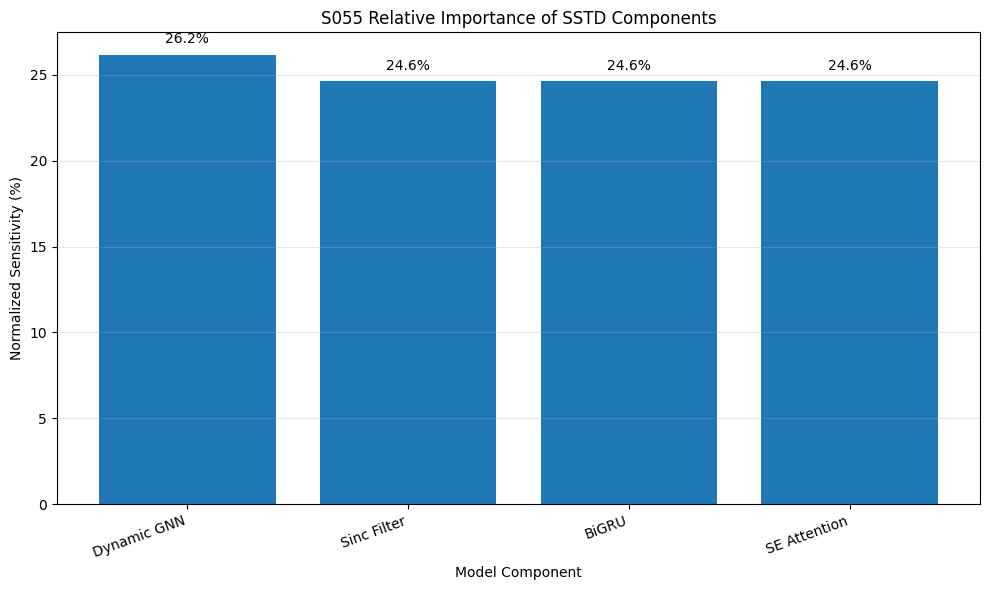


FINAL REPORT

Target Subject : S055
Baseline       : 86.67%

Dynamic GNN
  Ablated Accuracy : 48.89%
  Accuracy Drop    : 37.78 pp
  Relative Drop    : 43.59%

Sinc Filter
  Ablated Accuracy : 51.11%
  Accuracy Drop    : 35.56 pp
  Relative Drop    : 41.03%

BiGRU
  Ablated Accuracy : 51.11%
  Accuracy Drop    : 35.56 pp
  Relative Drop    : 41.03%

SE Attention
  Ablated Accuracy : 51.11%
  Accuracy Drop    : 35.56 pp
  Relative Drop    : 41.03%

--------------------------------------------------------------------------------
Files saved:
module_importance_results/S055_component_importance.csv
module_importance_results/S055_accuracy_drop.png
module_importance_results/S055_normalized_importance.png

Analysis completed.


In [51]:
# =====================================================================
# MASTER CELL
# SSTD COMPONENT IMPORTANCE / SENSITIVITY ANALYSIS
# =====================================================================
#
# This cell is completely self-contained with respect to:
#   model
#   train_loader
#   test_loader
#
# It retrains ONE target subject using the same pipeline and settings
# already defined in the notebook, performs AdaBN, evaluates the full
# model, then temporarily disables:
#
#   1. Sinc Filter Bank
#   2. Dynamic GNN
#   3. Bidirectional GRU
#   4. SE Attention
#
# and measures the resulting accuracy drop.
#
# IMPORTANT:
# This is sensitivity analysis of a trained model.
# It is NOT a retrained ablation study.
#
# =====================================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =====================================================================
# 1. USER SETTINGS
# =====================================================================

IMPORTANCE_TARGET = 55

IMPORTANCE_EPOCHS = EPOCHS

IMPORTANCE_BATCH_SIZE = BATCH_SIZE

IMPORTANCE_OUTPUT_DIR = Path(
    "./module_importance_results"
)

IMPORTANCE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 2. CHECK REQUIRED NOTEBOOK OBJECTS
# =====================================================================

required_objects = [
    "DATA_DIR",
    "TOTAL_SUBJECTS",
    "NUM_TRAIN_SUBJECTS",
    "SEED",
    "LEARNING_RATE",
    "WEIGHT_DECAY",
    "LABEL_SMOOTHING",
    "DOMAIN_WEIGHT",
    "SUPCON_WEIGHT",
    "SUPCON_TEMPERATURE",
    "GRADIENT_CLIP",
    "EEGMMIDB_Dataset",
    "SSTD_DomainAdaptationModel",
    "SupConLoss",
    "apply_adabn",
    "available_subjects",
    "DEVICE"
]


missing = [
    x
    for x in required_objects
    if x not in globals()
]


if missing:

    raise RuntimeError(
        "\nMissing notebook objects:\n\n"
        +
        "\n".join(
            f"  - {x}"
            for x in missing
        )
        +
        "\n\nRun the model/data/training definition cells first."
    )


# =====================================================================
# 3. REPRODUCIBILITY
# =====================================================================

def set_all_seeds(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)


set_all_seeds(
    SEED + IMPORTANCE_TARGET
)


# =====================================================================
# 4. CHECK TARGET SUBJECT
# =====================================================================

available = available_subjects(
    DATA_DIR,
    TOTAL_SUBJECTS
)


if IMPORTANCE_TARGET not in available:

    raise RuntimeError(
        f"S{IMPORTANCE_TARGET:03d} "
        f"is not available.\n\n"
        f"Available subjects:\n{available}"
    )


print("\n" + "=" * 80)
print("SSTD COMPONENT IMPORTANCE ANALYSIS")
print("=" * 80)

print(
    f"\nTarget subject : "
    f"S{IMPORTANCE_TARGET:03d}"
)

print(
    f"Device         : "
    f"{DEVICE}"
)

print(
    f"Epochs         : "
    f"{IMPORTANCE_EPOCHS}"
)


# =====================================================================
# 5. BUILD SOURCE SUBJECTS
# =====================================================================

remaining_subjects = [

    s

    for s in available

    if s != IMPORTANCE_TARGET

]


train_n = min(
    NUM_TRAIN_SUBJECTS,
    len(remaining_subjects)
)


rng = random.Random(
    SEED + IMPORTANCE_TARGET
)


train_subjects = rng.sample(
    remaining_subjects,
    train_n
)


print(
    f"\nSource subjects: "
    f"{len(train_subjects)}"
)

print(
    f"Target subjects: "
    f"S{IMPORTANCE_TARGET:03d}"
)


# =====================================================================
# 6. DATASETS
# =====================================================================

train_dataset = EEGMMIDB_Dataset(
    DATA_DIR,
    train_subjects
)


test_dataset = EEGMMIDB_Dataset(
    DATA_DIR,
    [IMPORTANCE_TARGET]
)


# =====================================================================
# 7. DATALOADERS
# =====================================================================

train_loader = torch.utils.data.DataLoader(

    train_dataset,

    batch_size=IMPORTANCE_BATCH_SIZE,

    shuffle=True,

    num_workers=0

)


test_loader = torch.utils.data.DataLoader(

    test_dataset,

    batch_size=IMPORTANCE_BATCH_SIZE,

    shuffle=False,

    num_workers=0

)


print(
    f"\nTraining trials : "
    f"{len(train_dataset)}"
)

print(
    f"Testing trials  : "
    f"{len(test_dataset)}"
)


# =====================================================================
# 8. CREATE MODEL
# =====================================================================

model = SSTD_DomainAdaptationModel(

    num_classes=2,

    num_subjects=TOTAL_SUBJECTS

).to(
    DEVICE
)


print(
    f"\nModel created: "
    f"{model.__class__.__name__}"
)


# =====================================================================
# 9. LOSSES
# =====================================================================

criterion_cls = nn.CrossEntropyLoss(

    label_smoothing=
        LABEL_SMOOTHING

)


criterion_domain = nn.CrossEntropyLoss()


criterion_supcon = SupConLoss(

    temperature=
        SUPCON_TEMPERATURE

)


# =====================================================================
# 10. OPTIMIZER
# =====================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)


# =====================================================================
# 11. SCHEDULER
# =====================================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=IMPORTANCE_EPOCHS,

    eta_min=1e-5

)


# =====================================================================
# 12. AMP
# =====================================================================

use_amp = (
    DEVICE.type == "cuda"
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=use_amp

)


# =====================================================================
# 13. TRAIN
# =====================================================================

print("\n" + "=" * 80)
print("TRAINING MODEL FOR COMPONENT ANALYSIS")
print("=" * 80)


for epoch in range(
    IMPORTANCE_EPOCHS
):

    model.train()

    epoch_loss = 0.0

    epoch_correct = 0

    epoch_total = 0


    total_batches = len(
        train_loader
    )


    for batch_idx, (
        x,
        y,
        subjects
    ) in enumerate(
        train_loader
    ):

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )

        subjects = subjects.to(
            DEVICE,
            non_blocking=True
        )


        # -------------------------------------------------------------
        # GRL schedule
        # -------------------------------------------------------------

        progress = float(

            batch_idx
            +
            epoch * total_batches

        ) / max(

            1,

            IMPORTANCE_EPOCHS *
            total_batches

        )


        lambda_grl = (

            2.0
            /
            (
                1.0
                +
                np.exp(
                    -10.0 * progress
                )
            )
            -
            1.0

        )


        # -------------------------------------------------------------
        # Clear gradients
        # -------------------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # -------------------------------------------------------------
        # Forward
        # -------------------------------------------------------------

        with torch.autocast(

            device_type=
                DEVICE.type,

            enabled=
                use_amp

        ):

            class_logits, \
            domain_logits, \
            z_proj = model(

                x,

                lambda_grl

            )


            loss_cls = criterion_cls(

                class_logits,

                y

            )


            loss_domain = criterion_domain(

                domain_logits,

                subjects

            )


            loss_supcon = criterion_supcon(

                z_proj,

                y

            )


            loss_total = (

                loss_cls

                +

                DOMAIN_WEIGHT
                *
                loss_domain

                +

                SUPCON_WEIGHT
                *
                loss_supcon

            )


        # -------------------------------------------------------------
        # Backpropagation
        # -------------------------------------------------------------

        scaler.scale(
            loss_total
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=
                GRADIENT_CLIP

        )


        scaler.step(
            optimizer
        )


        scaler.update()


        # -------------------------------------------------------------
        # Statistics
        # -------------------------------------------------------------

        batch_size = x.size(0)

        epoch_loss += (

            loss_total.detach()
            .float()
            .cpu()
            .item()
            *
            batch_size

        )


        predictions = torch.argmax(

            class_logits.detach(),

            dim=1

        )


        epoch_correct += (

            predictions == y

        ).sum().item()


        epoch_total += batch_size


    # -------------------------------------------------------------
    # Scheduler
    # -------------------------------------------------------------

    scheduler.step()


    train_loss = (
        epoch_loss /
        max(epoch_total, 1)
    )


    train_acc = (

        epoch_correct /
        max(epoch_total, 1)

    ) * 100.0


    # -------------------------------------------------------------
    # Progress
    # -------------------------------------------------------------

    if (

        epoch == 0

        or

        (epoch + 1) % 10 == 0

        or

        epoch == IMPORTANCE_EPOCHS - 1

    ):

        print(

            f"Epoch "
            f"{epoch + 1:03d}/"
            f"{IMPORTANCE_EPOCHS:03d} | "
            f"Loss={train_loss:.4f} | "
            f"TrainAcc={train_acc:.2f}%"

        )


# =====================================================================
# 14. ACCURACY FUNCTION
# =====================================================================

def evaluate_accuracy(
    model,
    loader
):

    model.eval()

    correct = 0

    total = 0


    with torch.no_grad():

        for batch in loader:

            x = batch[0].to(
                DEVICE
            )

            y = batch[1].to(
                DEVICE
            )


            outputs = model(

                x,

                lambda_grl=0.0

            )


            logits = outputs[0]


            pred = torch.argmax(

                logits,

                dim=1

            )


            correct += (

                pred == y

            ).sum().item()


            total += y.numel()


    return (
        correct /
        max(total, 1)
    )


# =====================================================================
# 15. BASELINE BEFORE AdaBN
# =====================================================================

baseline_before_adabn = evaluate_accuracy(
    model,
    test_loader
)


print("\n" + "-" * 80)

print(
    f"Target accuracy BEFORE AdaBN: "
    f"{baseline_before_adabn * 100:.2f}%"
)


# =====================================================================
# 16. APPLY AdaBN
# =====================================================================

print(
    "\nApplying AdaBN..."
)


model = apply_adabn(

    model,

    test_loader,

    DEVICE,

    adaptation_trials=
        len(test_dataset)

)


# =====================================================================
# 17. BASELINE AFTER AdaBN
# =====================================================================

baseline_accuracy = evaluate_accuracy(

    model,

    test_loader

)


baseline_percent = (
    baseline_accuracy * 100.0
)


print(
    f"Baseline accuracy AFTER AdaBN: "
    f"{baseline_percent:.2f}%"
)


# =====================================================================
# 18. LOCATE MODEL COMPONENTS
# =====================================================================

print("\n" + "=" * 80)
print("MODEL COMPONENTS")
print("=" * 80)


components = {

    "Sinc Filter":
        model.sinc_filter,

    "Dynamic GNN":
        model.dgnn,

    "BiGRU":
        model.bigru,

    "SE Attention":
        model.se_attention

}


for name, module in components.items():

    print(
        f"✓ {name:20s} "
        f"-> {module.__class__.__name__}"
    )


# =====================================================================
# 19. ZERO-OUTPUT HOOK
# =====================================================================

def zero_module_output(
    module,
    inputs,
    output
):

    # -------------------------------------------------------------
    # Standard tensor
    # -------------------------------------------------------------

    if torch.is_tensor(output):

        return torch.zeros_like(
            output
        )


    # -------------------------------------------------------------
    # Tuple
    # -------------------------------------------------------------

    if isinstance(
        output,
        tuple
    ):

        modified = []

        for value in output:

            if torch.is_tensor(value):

                modified.append(
                    torch.zeros_like(value)
                )

            else:

                modified.append(
                    value
                )

        return tuple(
            modified
        )


    return output


# =====================================================================
# 20. COMPONENT SENSITIVITY
# =====================================================================

importance_results = []


print("\n" + "=" * 80)
print("COMPONENT SENSITIVITY")
print("=" * 80)


for component_name, module in components.items():

    print(
        f"\nTesting {component_name}..."
    )


    hook = module.register_forward_hook(

        zero_module_output

    )


    try:

        ablated_accuracy = evaluate_accuracy(

            model,

            test_loader

        )

    finally:

        hook.remove()


    ablated_percent = (
        ablated_accuracy * 100.0
    )


    accuracy_drop = (

        baseline_percent
        -
        ablated_percent

    )


    relative_drop = (

        accuracy_drop
        /
        max(
            baseline_percent,
            1e-12
        )

    ) * 100.0


    importance_results.append({

        "Component":
            component_name,

        "Baseline Accuracy (%)":
            baseline_percent,

        "Ablated Accuracy (%)":
            ablated_percent,

        "Accuracy Drop (pp)":
            accuracy_drop,

        "Relative Drop (%)":
            relative_drop

    })


    print(

        f"  Full model : "
        f"{baseline_percent:.2f}%"

    )

    print(

        f"  Ablated    : "
        f"{ablated_percent:.2f}%"

    )

    print(

        f"  Drop       : "
        f"{accuracy_drop:.2f} pp"

    )


# =====================================================================
# 21. CREATE DATAFRAME
# =====================================================================

importance_df = pd.DataFrame(
    importance_results
)


importance_df = (

    importance_df

    .sort_values(

        "Accuracy Drop (pp)",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


importance_df.insert(

    0,

    "Rank",

    np.arange(
        1,
        len(importance_df) + 1
    )

)


# =====================================================================
# 22. NORMALIZED SENSITIVITY
# =====================================================================

positive_drops = np.maximum(

    importance_df[
        "Accuracy Drop (pp)"
    ].to_numpy(),

    0.0

)


drop_sum = positive_drops.sum()


if drop_sum > 0:

    normalized = (

        positive_drops /
        drop_sum

    ) * 100.0

else:

    normalized = np.zeros_like(
        positive_drops
    )


importance_df[
    "Normalized Sensitivity (%)"
] = normalized


# =====================================================================
# 23. DISPLAY RESULTS
# =====================================================================

print("\n" + "=" * 80)
print("FINAL COMPONENT IMPORTANCE TABLE")
print("=" * 80)

display(
    importance_df
)


# =====================================================================
# 24. SAVE CSV
# =====================================================================

csv_path = (

    IMPORTANCE_OUTPUT_DIR
    /
    f"S{IMPORTANCE_TARGET:03d}_component_importance.csv"

)


importance_df.to_csv(

    csv_path,

    index=False

)


# =====================================================================
# 25. GRAPH — ACCURACY DROP
# =====================================================================

plt.figure(
    figsize=(10, 6)
)


bars = plt.bar(

    importance_df[
        "Component"
    ],

    importance_df[
        "Accuracy Drop (pp)"
    ]

)


plt.axhline(
    0,
    linewidth=1
)


plt.ylabel(
    "Accuracy Drop (percentage points)"
)


plt.xlabel(
    "Model Component"
)


plt.title(

    f"S{IMPORTANCE_TARGET:03d} "
    f"SSTD Component Sensitivity"

)


plt.xticks(

    rotation=20,

    ha="right"

)


plt.grid(

    axis="y",

    alpha=0.30

)


for bar, value in zip(

    bars,

    importance_df[
        "Accuracy Drop (pp)"
    ]

):

    y = (

        bar.get_height()
        +
        0.5

        if value >= 0

        else

        bar.get_height()
        -
        0.5

    )


    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        y,

        f"{value:.2f} pp",

        ha="center",

        va=(
            "bottom"
            if value >= 0
            else "top"
        )

    )


plt.tight_layout()


drop_plot_path = (

    IMPORTANCE_OUTPUT_DIR
    /
    f"S{IMPORTANCE_TARGET:03d}_accuracy_drop.png"

)


plt.savefig(

    drop_plot_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# =====================================================================
# 26. GRAPH — NORMALIZED SENSITIVITY
# =====================================================================

plt.figure(
    figsize=(10, 6)
)


bars = plt.bar(

    importance_df[
        "Component"
    ],

    importance_df[
        "Normalized Sensitivity (%)"
    ]

)


plt.ylabel(
    "Normalized Sensitivity (%)"
)


plt.xlabel(
    "Model Component"
)


plt.title(

    f"S{IMPORTANCE_TARGET:03d} "
    f"Relative Importance of SSTD Components"

)


plt.xticks(

    rotation=20,

    ha="right"

)


plt.grid(

    axis="y",

    alpha=0.30

)


for bar, value in zip(

    bars,

    importance_df[
        "Normalized Sensitivity (%)"
    ]

):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height() + 0.5,

        f"{value:.1f}%",

        ha="center",

        va="bottom"

    )


plt.tight_layout()


normalized_plot_path = (

    IMPORTANCE_OUTPUT_DIR
    /
    f"S{IMPORTANCE_TARGET:03d}_normalized_importance.png"

)


plt.savefig(

    normalized_plot_path,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# =====================================================================
# 27. FINAL REPORT
# =====================================================================

print("\n" + "=" * 80)
print("FINAL REPORT")
print("=" * 80)

print(
    f"\nTarget Subject : "
    f"S{IMPORTANCE_TARGET:03d}"
)

print(
    f"Baseline       : "
    f"{baseline_percent:.2f}%"
)


for _, row in importance_df.iterrows():

    print(

        f"\n{row['Component']}"

    )

    print(

        f"  Ablated Accuracy : "
        f"{row['Ablated Accuracy (%)']:.2f}%"

    )

    print(

        f"  Accuracy Drop    : "
        f"{row['Accuracy Drop (pp)']:.2f} pp"

    )

    print(

        f"  Relative Drop    : "
        f"{row['Relative Drop (%)']:.2f}%"

    )


print("\n" + "-" * 80)

print(
    "Files saved:"
)

print(
    csv_path
)

print(
    drop_plot_path
)

print(
    normalized_plot_path
)

print("\nAnalysis completed.")